#Import Datasets#

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [ ]:
itac = pd.read_csv('/content/drive/MyDrive/WhisperData/itac_compact.csv')
sic = pd.read_csv('/content/drive/MyDrive/WhisperData/sic-codes.csv')

In [ ]:
itac.head()

,ID,CENTER,FY,SIC,NAICS,STATE,ANNUAL_SALES,EMPLOYEES,PLANT_AREA,ANNUAL_ELECTRICITY_COST,...,TOTAL_RECC_SAVINGS,ROI_YRS,PRODUCTS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,ARC2,IMPSTATUS
0,AM0001,AM,1987,3671.0,NaN,TX,33900000.0,206.0,NaN,184985.0,...,4479.0,3.562402,MICRO & MINI COMPUTERS,1.0,310.0,2250.0,7,7,"2.8114,2.7142,2.7111,2.7447,2.7233,2.7111,2.7111","N,N,N,I,N,N,N"
1,AM0002,AM,1987,2761.0,NaN,TX,25000000.0,156.0,NaN,338359.0,...,109532.0,0.672644,BUSINESS FORMS,NaN,NaN,2250.0,9,9,"2.6221,2.7226,2.6212,2.4111,2.7142,2.7142,2.71...","I,I,I,N,I,I,I,I,I"
2,AM0003,AM,1987,3494.0,NaN,TX,15000000.0,200.0,NaN,139480.0,...,16001.0,0.982689,SAFETY JOINTS & VALVES,NaN,NaN,2250.0,8,8,"2.3212,2.7224,2.7111,2.4111,2.7142,2.7142,2.24...","N,N,N,N,N,I,N,I"
3,AM0004,AM,1987,3713.0,NaN,TX,4200000.0,75.0,NaN,68986.0,...,17607.0,1.273868,TRUCKS BEDS & TRAILERS,1.0,1000.0,2340.0,11,11,"2.6218,2.7142,2.7142,2.4236,2.7142,2.6232,2.62...","I,I,I,I,N,N,N,I,N,N,N"
4,AM0005,AM,1987,2024.0,NaN,TX,12000000.0,39.0,NaN,185065.0,...,3402.0,2.190770,ICE CREAM,5.0,2000.0,2080.0,7,7,"2.7142,2.7142,2.7142,2.2449,2.4111,2.1233,2.8112","I,I,N,N,N,I,N"


In [ ]:
sic.head()

,Division,Major Group,Industry Group,SIC,Description
0,A,1,11,111,Wheat
1,A,1,11,112,Rice
2,A,1,11,115,Corn
3,A,1,11,116,Soybeans
4,A,1,11,119,"Cash Grains, Not Elsewhere Classified"


In [ ]:
itac['SIC'] = itac['SIC'].astype('Int64')
sic['SIC']  = sic['SIC'].astype('Int64')
df = pd.merge(
    itac,
    sic,
    on='SIC',
    how='left',
    validate='many_to_one'
)
df.head()

,ID,CENTER,FY,SIC,NAICS,STATE,ANNUAL_SALES,EMPLOYEES,PLANT_AREA,ANNUAL_ELECTRICITY_COST,...,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,ARC2,IMPSTATUS,Division,Major Group,Industry Group,Description
0,AM0001,AM,1987,3671,NaN,TX,33900000.0,206.0,NaN,184985.0,...,310.0,2250.0,7,7,"2.8114,2.7142,2.7111,2.7447,2.7233,2.7111,2.7111","N,N,N,I,N,N,N",D,36.0,367.0,Electron Tubes
1,AM0002,AM,1987,2761,NaN,TX,25000000.0,156.0,NaN,338359.0,...,NaN,2250.0,9,9,"2.6221,2.7226,2.6212,2.4111,2.7142,2.7142,2.71...","I,I,I,N,I,I,I,I,I",D,27.0,276.0,Manifold Business Forms
2,AM0003,AM,1987,3494,NaN,TX,15000000.0,200.0,NaN,139480.0,...,NaN,2250.0,8,8,"2.3212,2.7224,2.7111,2.4111,2.7142,2.7142,2.24...","N,N,N,N,N,I,N,I",D,34.0,349.0,"Valves and Pipe Fittings, Not Elsewhere Classi..."
3,AM0004,AM,1987,3713,NaN,TX,4200000.0,75.0,NaN,68986.0,...,1000.0,2340.0,11,11,"2.6218,2.7142,2.7142,2.4236,2.7142,2.6232,2.62...","I,I,I,I,N,N,N,I,N,N,N",D,37.0,371.0,Truck and Bus Bodies
4,AM0005,AM,1987,2024,NaN,TX,12000000.0,39.0,NaN,185065.0,...,2000.0,2080.0,7,7,"2.7142,2.7142,2.7142,2.2449,2.4111,2.1233,2.8112","I,I,N,N,N,I,N",D,20.0,202.0,Ice Cream and Frozen Desserts


In [ ]:
df.columns

Index(['ID', 'CENTER', 'FY', 'SIC', 'NAICS', 'STATE', 'ANNUAL_SALES',
       'EMPLOYEES', 'PLANT_AREA', 'ANNUAL_ELECTRICITY_COST',
       'TOTAL_RECC_IMP_COST', 'TOTAL_RECC_SAVINGS', 'ROI_YRS', 'PRODUCTS',
       'PRODUNITS', 'PRODLEVEL', 'PRODHOURS', 'NUMARS', 'num_reccs', 'ARC2',
       'IMPSTATUS', 'Division', 'Major Group', 'Industry Group',
       'Description'],
      dtype='object')

In [ ]:
df.shape

(22134, 25)

#Data Filtering and Sector Independent Analysis#

In [ ]:
df = df[
    (df['FY']>=2018)&
    (df['STATE']=="CA")&
    (df['ANNUAL_ELECTRICITY_COST'] > 100_000) &
    (df['ANNUAL_ELECTRICITY_COST'] < 3_000_000) &
    (df['TOTAL_RECC_SAVINGS']    >= 100_000) &
    (df['ROI_YRS']              <=   5)
].copy()

df.shape


(132, 25)

In [ ]:
df.describe()

,FY,SIC,NAICS,ANNUAL_SALES,EMPLOYEES,PLANT_AREA,ANNUAL_ELECTRICITY_COST,TOTAL_RECC_IMP_COST,TOTAL_RECC_SAVINGS,ROI_YRS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,Major Group,Industry Group
count,132.000000,132.0,132.000000,1.320000e+02,132.000000,1.320000e+02,1.320000e+02,1.320000e+02,1.320000e+02,132.000000,61.000000,1.320000e+02,132.000000,132.000000,132.000000,132.000000,132.000000
mean,2022.681818,3396.94697,335277.113636,5.659956e+07,123.189394,2.611089e+05,8.312068e+05,7.379571e+05,3.691205e+05,2.261986,2.885246,3.303976e+07,5451.181818,8.386364,8.386364,33.363636,339.189394
std,2.061342,1368.312831,82690.913875,1.153520e+08,110.331294,9.427637e+05,7.036664e+05,1.119530e+06,4.455994e+05,1.237798,1.592674,1.749816e+08,2211.578341,2.467028,2.467028,13.760366,136.887826
min,2018.000000,2013.0,32541.000000,1.000000e+05,1.000000,1.200000e+04,1.034830e+05,2.917300e+04,1.003840e+05,0.179674,1.000000,1.000000e+00,1500.000000,3.000000,3.000000,20.000000,201.000000
25%,2022.000000,2438.0,312127.500000,1.000000e+07,51.500000,4.000000e+04,3.226192e+05,2.623328e+05,1.471888e+05,1.031475,2.000000,9.624250e+03,4000.000000,7.000000,7.000000,23.500000,243.500000
50%,2023.000000,3398.0,327605.500000,2.000000e+07,85.000000,8.867950e+04,5.667930e+05,5.214025e+05,2.061600e+05,2.243753,2.000000,1.100000e+05,5226.000000,8.000000,8.000000,33.000000,339.000000
75%,2024.000000,3674.75,334418.000000,6.726658e+07,171.750000,2.212500e+05,1.035358e+06,8.345510e+05,3.937358e+05,3.324805,5.000000,4.726875e+06,7086.000000,10.000000,10.000000,36.000000,367.000000
max,2025.000000,8322.0,812332.000000,9.500000e+08,559.000000,1.050000e+07,2.926207e+06,1.155972e+07,2.835679e+06,4.672739,6.000000,1.500000e+09,8760.000000,16.000000,16.000000,83.000000,832.000000


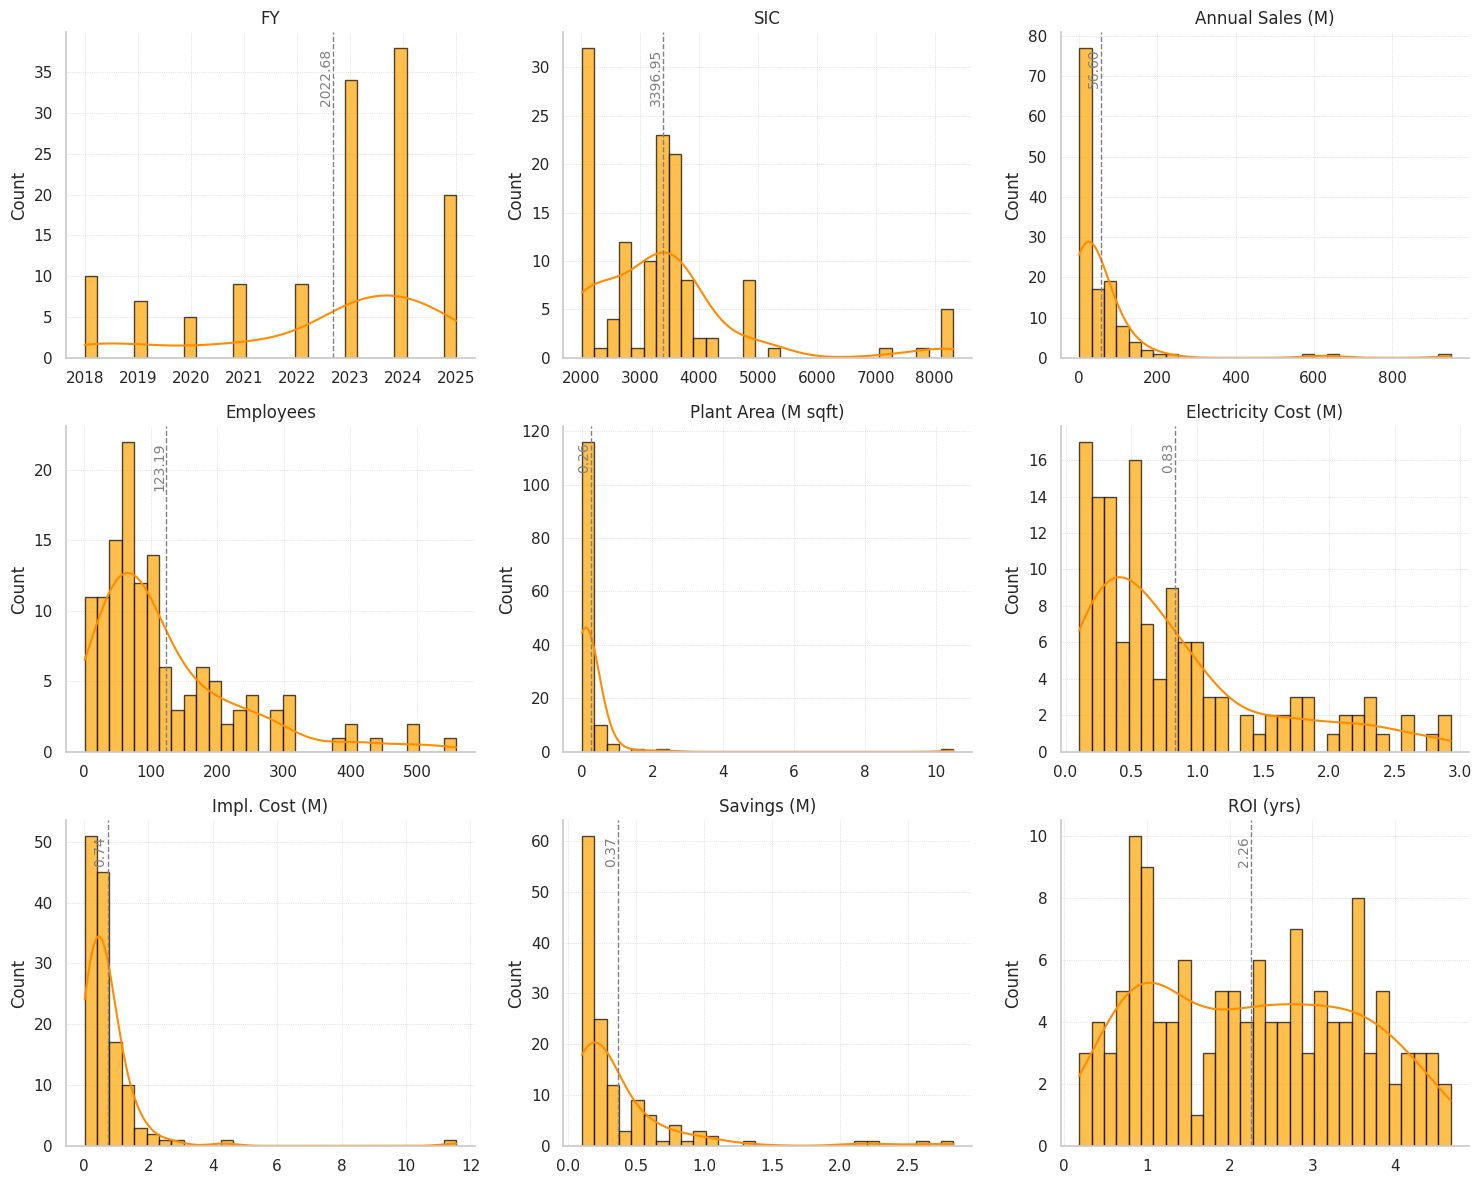

In [ ]:
df_plot = df.copy()
to_mil = [
    'ANNUAL_SALES',
    'ANNUAL_ELECTRICITY_COST',
    'TOTAL_RECC_IMP_COST',
    'TOTAL_RECC_SAVINGS',
    'PLANT_AREA'
]
for col in to_mil:
    df_plot[col] = df_plot[col] / 1e6
df_plot = df_plot.rename(columns={
    'ANNUAL_SALES':            'Annual Sales (M)',
    'ANNUAL_ELECTRICITY_COST': 'Electricity Cost (M)',
    'TOTAL_RECC_IMP_COST':     'Impl. Cost (M)',
    'TOTAL_RECC_SAVINGS':      'Savings (M)',
    'PLANT_AREA':              'Plant Area (M sqft)',
    'EMPLOYEES':               'Employees',
    'ROI_YRS':                 'ROI (yrs)'
})
plot_cols = [
    'FY',
    'SIC',
    'Annual Sales (M)',
    'Employees',
    'Plant Area (M sqft)',
    'Electricity Cost (M)',
    'Impl. Cost (M)',
    'Savings (M)',
    'ROI (yrs)'
]

def hist_with_kde(ax, series):
    data = series.dropna()
    counts, bins, _ = ax.hist(
        data, bins=30, density=False,
        color='orange', edgecolor='black', alpha=0.7
    )
    kde = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    bin_w = bins[1] - bins[0]
    ax.plot(xs, kde(xs) * len(data) * bin_w,
            color='darkorange', linewidth=1.5)
    mu = data.mean()
    ax.axvline(mu, linestyle='--', color='gray', linewidth=1)
    y_top = ax.get_ylim()[1]
    ax.text(mu, y_top*0.95, f'{mu:.2f}',
            rotation=90, va='top', ha='right',
            color='gray', fontsize='small')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.5)
    ax.set_ylabel('Count')
    ax.set_xlabel('')
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    hist_with_kde(ax, df_plot[col])
    ax.set_title(col)
for ax in axes[len(plot_cols):]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()





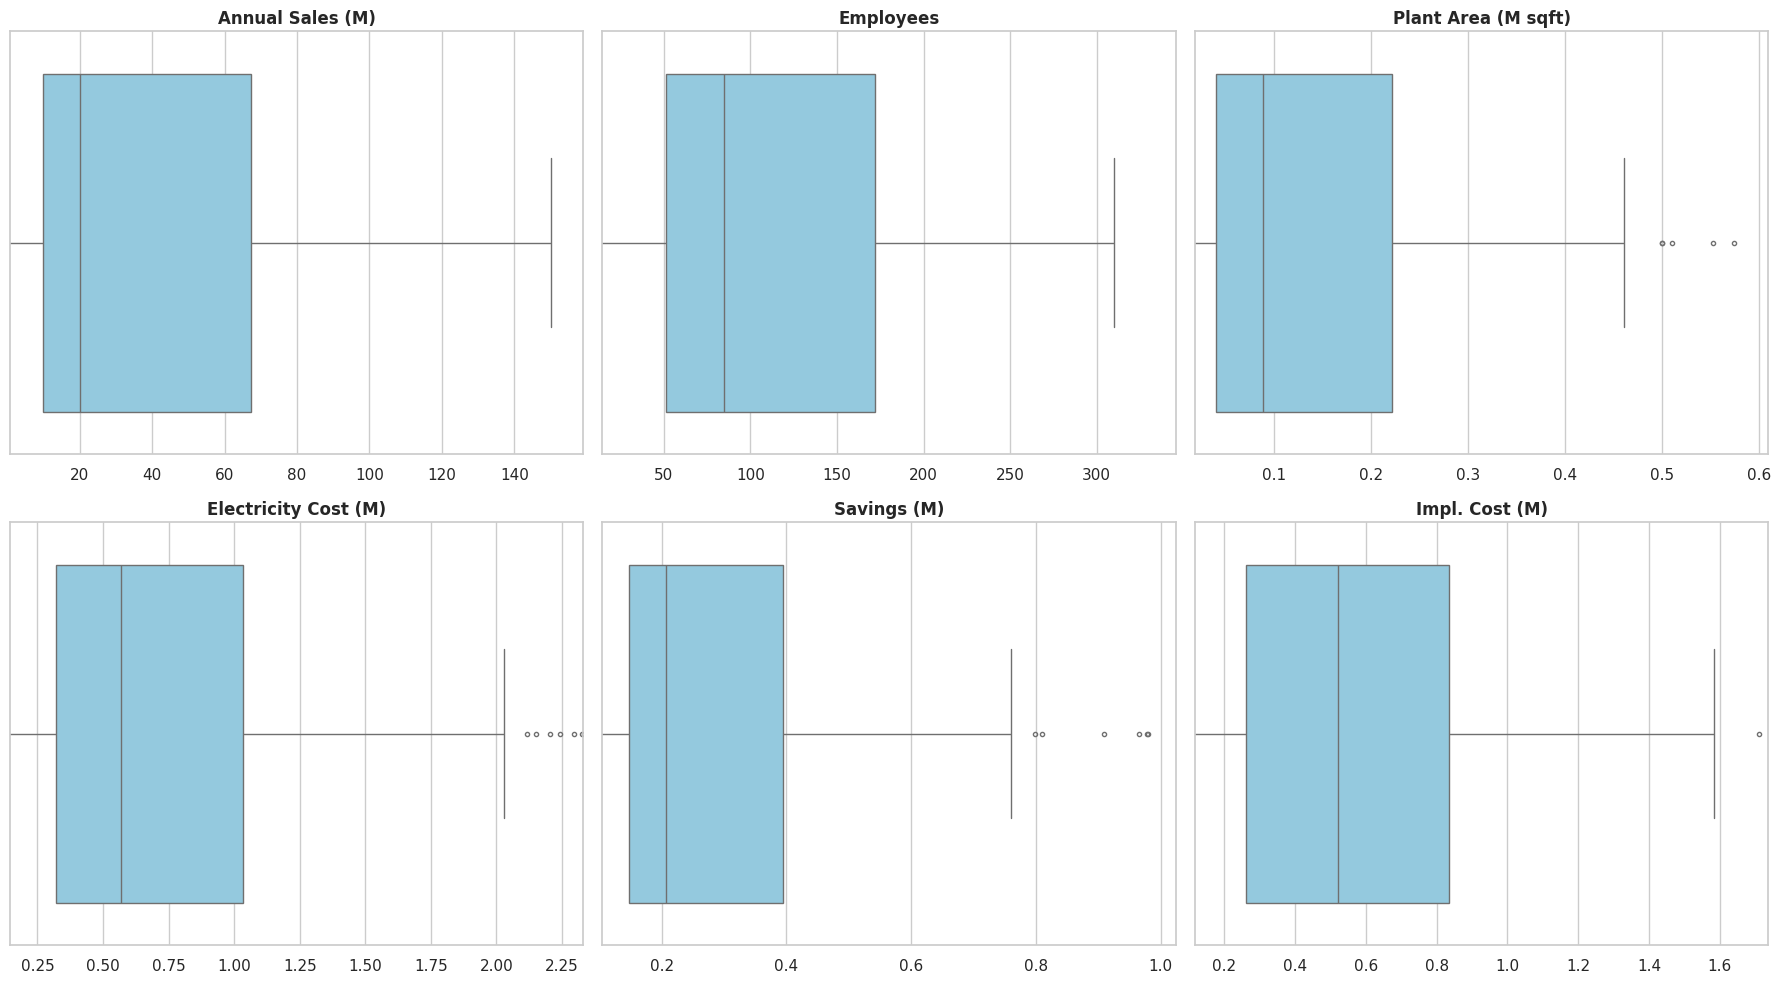

In [ ]:
zoom_cols = [
    'Annual Sales (M)',
    'Employees',
    'Plant Area (M sqft)',
    'Electricity Cost (M)',
    'Savings (M)',
    'Impl. Cost (M)'
]
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, zoom_cols):
    data = df_plot[col].dropna()
    sns.boxplot(x=data, ax=ax, color="skyblue", fliersize=3, linewidth=1)

    # compute 5th & 95th percentiles and set limits
    lower, upper = data.quantile([0.05, 0.95])
    ax.set_xlim(lower, upper)

    ax.set_title(col, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
for ax in axes[len(zoom_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


Getting the Average Profile

In [ ]:
profile_cols = df_plot.select_dtypes(include='number').columns
avg_series = df_plot[profile_cols].mean()
avg_profile_df = pd.DataFrame([avg_series])
avg_profile_df.index = ['Overall Mean']
avg_profile_df

,FY,SIC,NAICS,Annual Sales (M),Employees,Plant Area (M sqft),Electricity Cost (M),Impl. Cost (M),Savings (M),ROI (yrs),PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,num_reccs,Major Group,Industry Group
Overall Mean,2022.681818,3396.94697,335277.113636,56.59956,123.189394,0.261109,0.831207,0.737957,0.369121,2.261986,2.885246,3.303976e+07,5451.181818,8.386364,8.386364,33.363636,339.189394


#Industry Analysis#

In [ ]:
raw_data = df.copy()
work_data = raw_data.copy()
work_data['AnnualElec(M)'] = work_data['ANNUAL_ELECTRICITY_COST'] / 1e6
work_data['Savings(M)']    = work_data['TOTAL_RECC_SAVINGS']       / 1e6
work_data['ROI(yrs)']      = work_data['ROI_YRS']
sic_lookup = work_data.drop_duplicates('SIC').set_index('SIC')['Description']
sns.set_theme(style="whitegrid")



*Top 10 Major Groups along all dims*

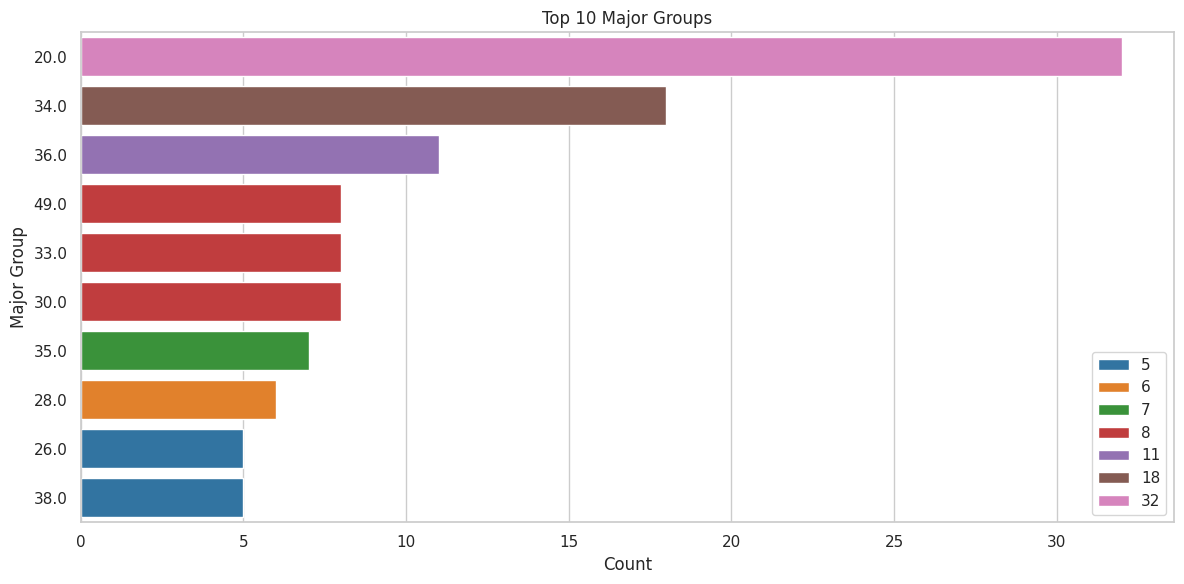

In [ ]:

mg_counts = work_data['Major Group'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=mg_counts.values, y=mg_counts.index.astype(str),hue=mg_counts.values ,palette='tab10')
plt.title("Top 10 Major Groups")
plt.xlabel("Count")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


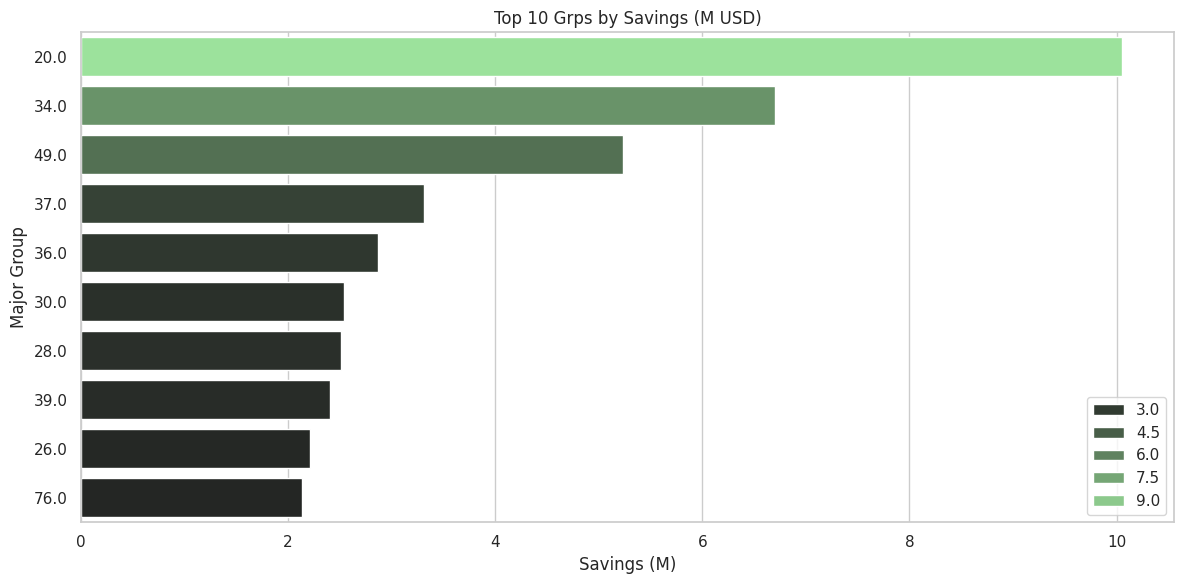

In [ ]:
savings_by_grp = (work_data
                  .groupby('Major Group')['Savings(M)']
                  .sum()
                  .nlargest(10))
plt.figure(figsize=(12,6))
sns.barplot(x=savings_by_grp.values, y=savings_by_grp.index.astype(str),hue = savings_by_grp.values, palette='dark:lightgreen')
plt.title("Top 10 Grps by Savings (M USD)")
plt.xlabel("Savings (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()

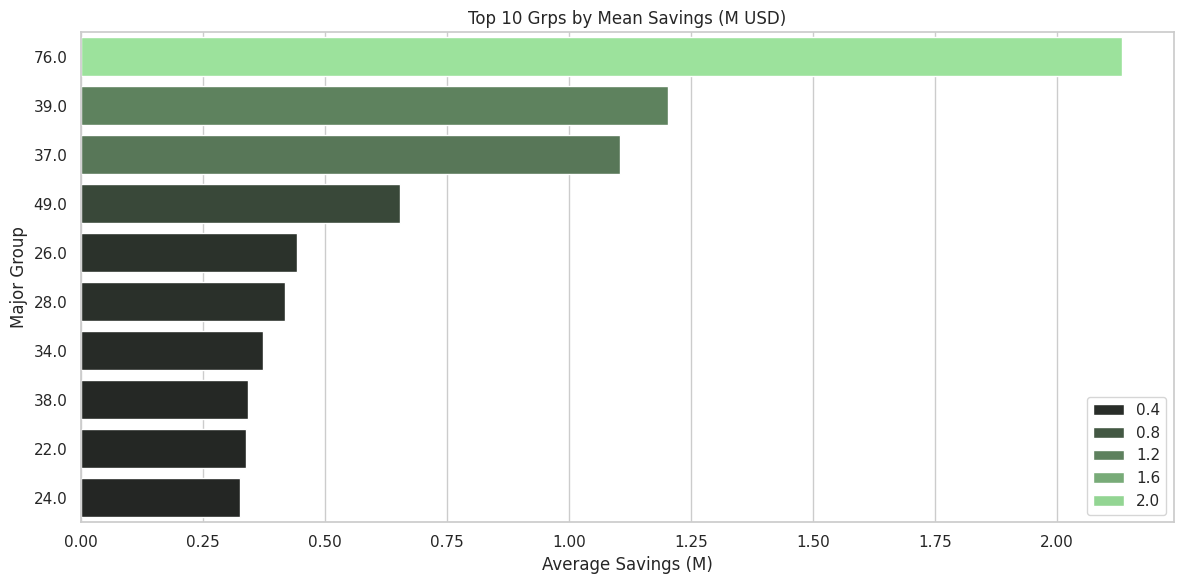

In [ ]:
# 2) Mean Savings
savings_by_grp_mu = (
    work_data
    .groupby('Major Group')['Savings(M)']
    .mean()
    .nlargest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=savings_by_grp_mu.values,
    y=savings_by_grp_mu.index.astype(str),
    hue=savings_by_grp_mu.values,
    palette='dark:lightgreen'
)
plt.title("Top 10 Grps by Mean Savings (M USD)")
plt.xlabel("Average Savings (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


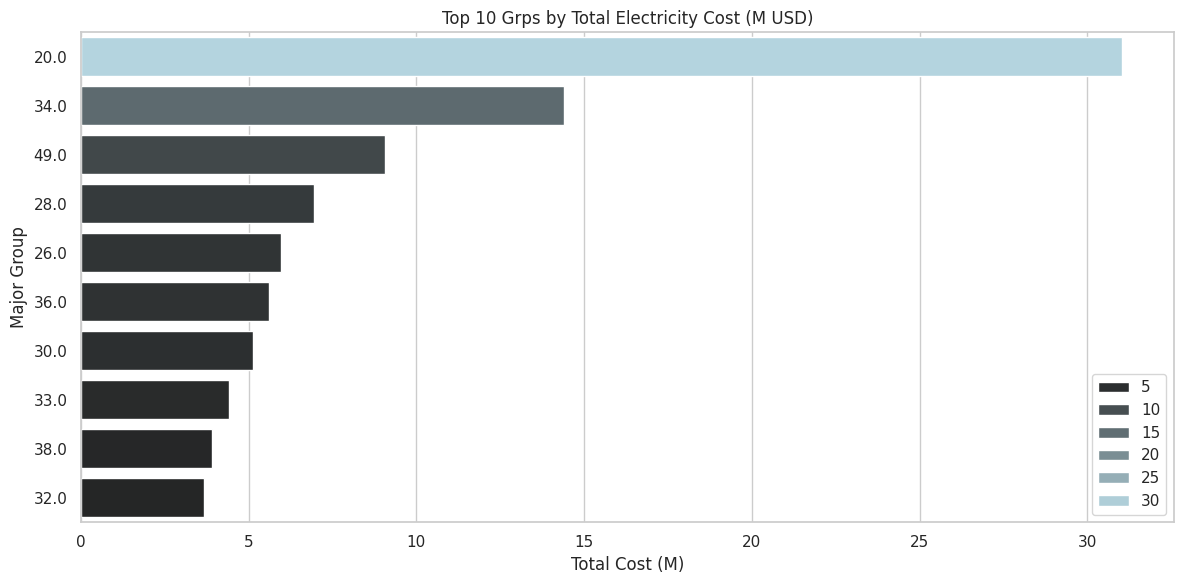

In [ ]:
# 3) Total Electricity Cost
cost_by_grp = (
    work_data
    .groupby('Major Group')['AnnualElec(M)']
    .sum()
    .nlargest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=cost_by_grp.values,
    y=cost_by_grp.index.astype(str),
    hue=cost_by_grp.values,
    palette='dark:lightblue'
)
plt.title("Top 10 Grps by Total Electricity Cost (M USD)")
plt.xlabel("Total Cost (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


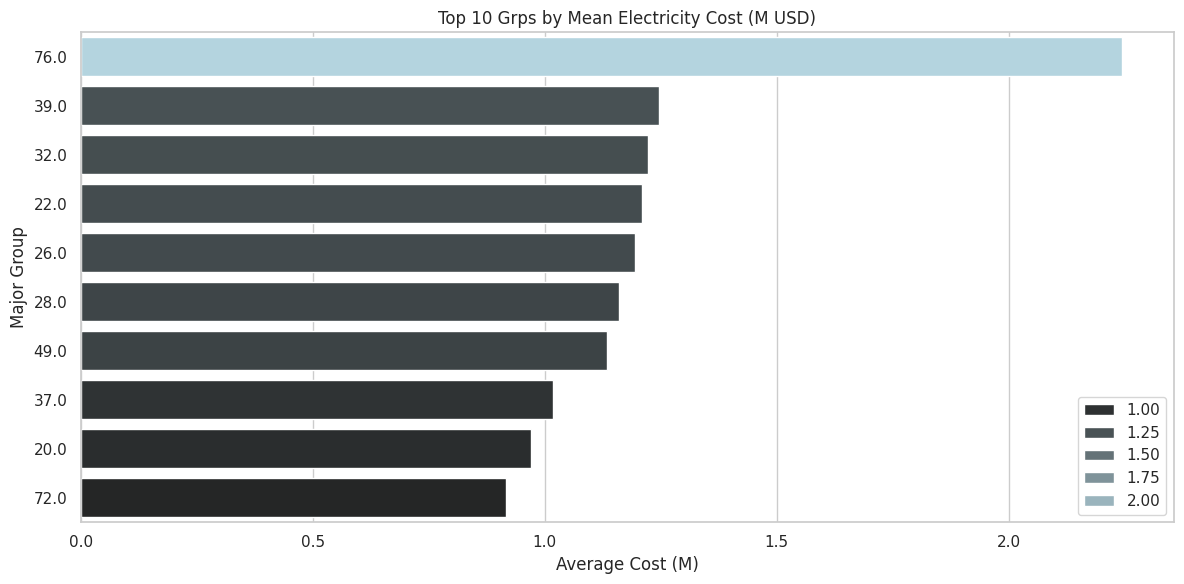

In [ ]:
# 4) Mean Electricity Cost
cost_by_grp_mu = (
    work_data
    .groupby('Major Group')['AnnualElec(M)']
    .mean()
    .nlargest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=cost_by_grp_mu.values,
    y=cost_by_grp_mu.index.astype(str),
    hue=cost_by_grp_mu.values,
    palette='dark:lightblue'
)
plt.title("Top 10 Grps by Mean Electricity Cost (M USD)")
plt.xlabel("Average Cost (M)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


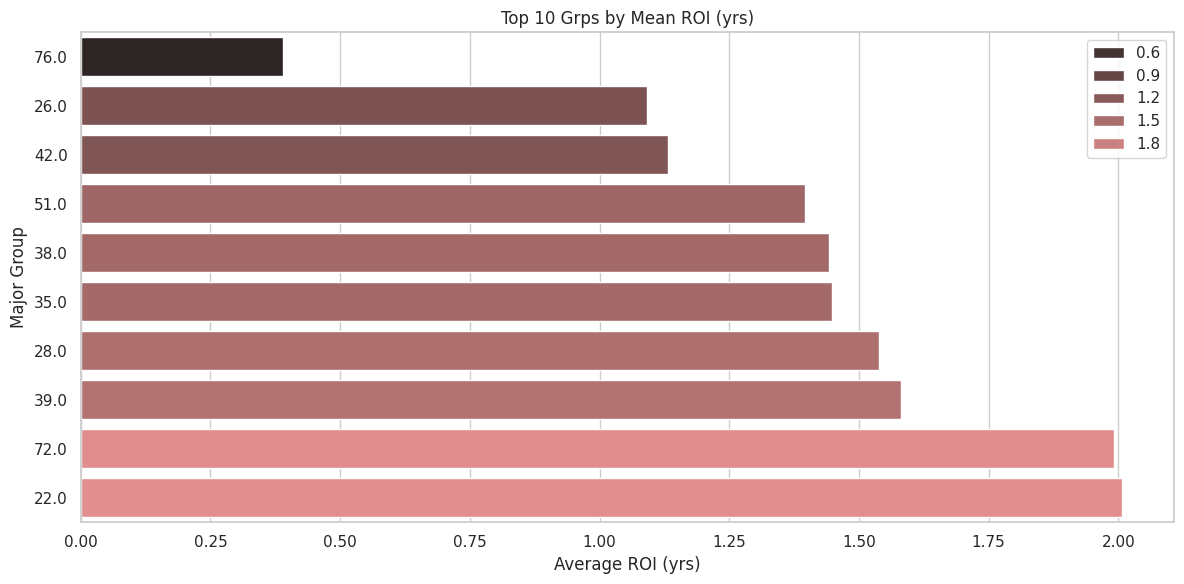

In [ ]:
# 6) Mean ROI
roi_by_grp_mu = (
    work_data
    .groupby('Major Group')['ROI(yrs)']
    .mean()
    .nsmallest(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=roi_by_grp_mu.values,
    y=roi_by_grp_mu.index.astype(str),
    hue=roi_by_grp_mu.values,
    palette='dark:lightcoral'
)
plt.title("Top 10 Grps by Mean ROI (yrs)")
plt.xlabel("Average ROI (yrs)")
plt.ylabel("Major Group")
plt.tight_layout()
plt.show()


*Top 10 SIC codes*

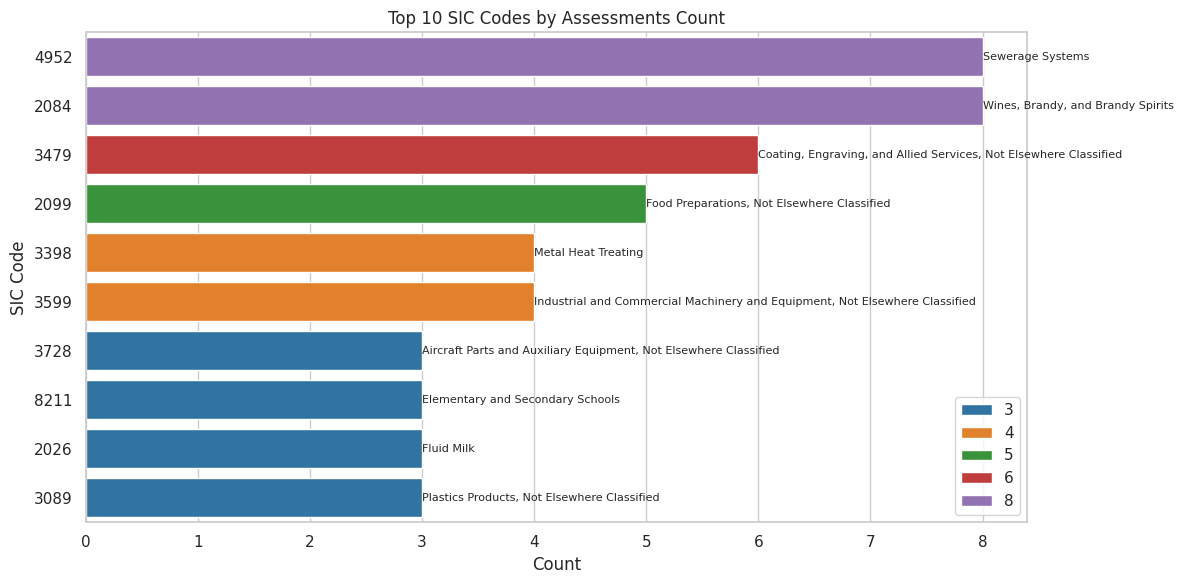

In [ ]:

sic_counts = work_data['SIC'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=sic_counts.values, y=sic_counts.index.astype(str),hue = sic_counts.values, palette='tab10')
plt.title("Top 10 SIC Codes by Assessments Count")
plt.xlabel("Count")
plt.ylabel("SIC Code")

for i,(code,val) in enumerate(zip(sic_counts.index, sic_counts.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


*Top 10 Industries by Savings*

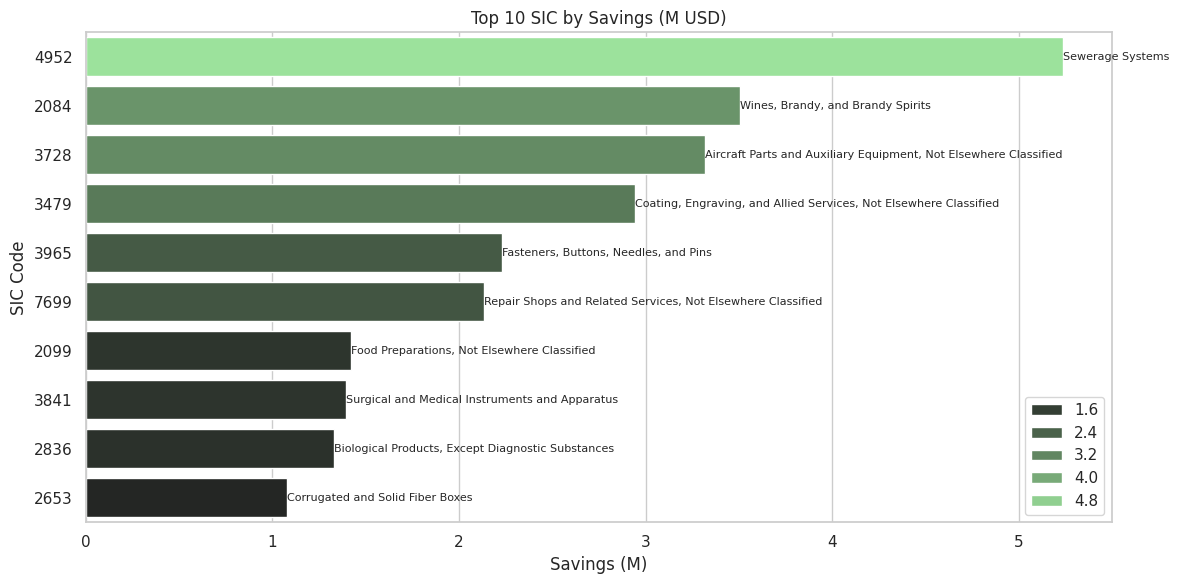

In [ ]:
savings_by_sic = (work_data
                  .groupby('SIC')['Savings(M)']
                  .sum()
                  .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=savings_by_sic.values, y=savings_by_sic.index.astype(str),hue = savings_by_sic.values, palette='dark:lightgreen')
plt.title("Top 10 SIC by Savings (M USD)")
plt.xlabel("Savings (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(savings_by_sic.index, savings_by_sic.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


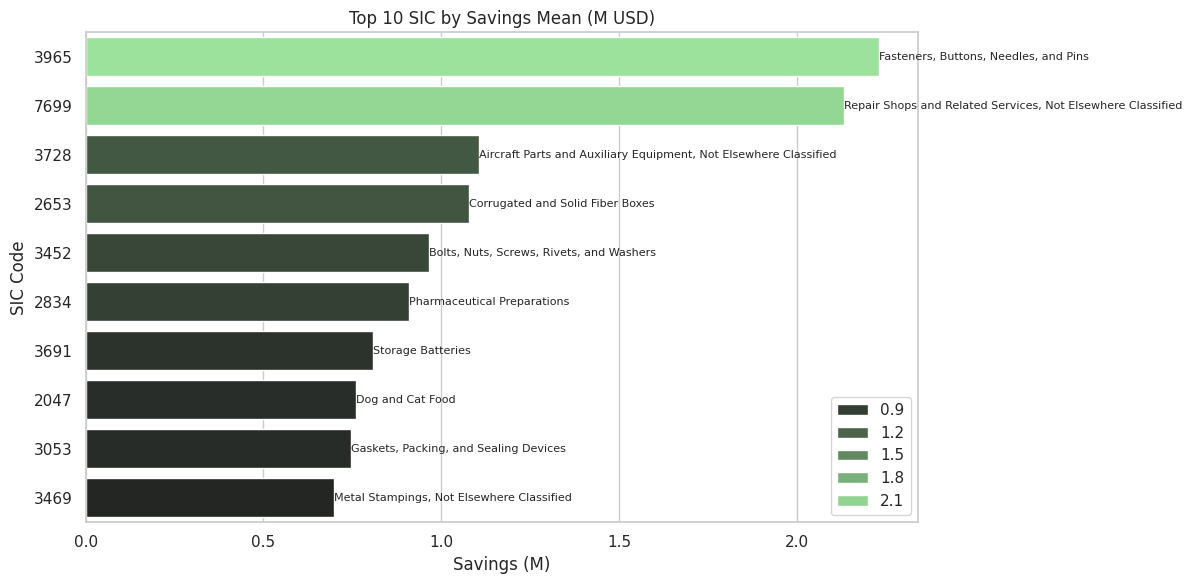

In [ ]:
savings_by_sic_mu = (work_data
                  .groupby('SIC')['Savings(M)']
                  .mean()
                  .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=savings_by_sic_mu.values, y=savings_by_sic_mu.index.astype(str),hue = savings_by_sic_mu.values, palette='dark:lightgreen')
plt.title("Top 10 SIC by Savings Mean (M USD)")
plt.xlabel("Savings (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(savings_by_sic_mu.index, savings_by_sic_mu.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()

*Top 10 Industries by Electricity Costs*

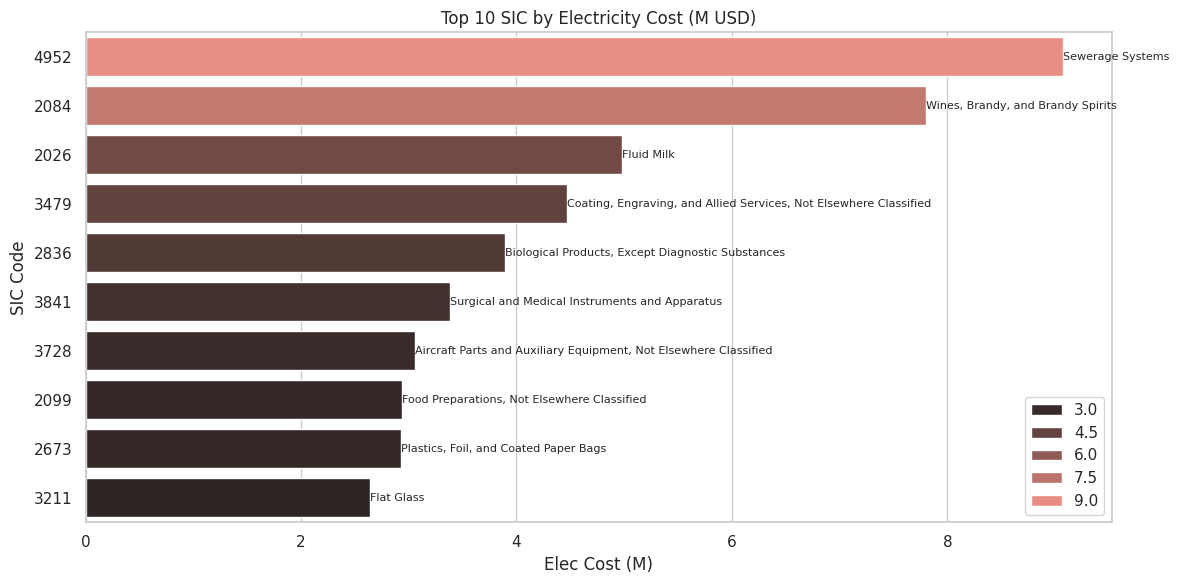

In [ ]:

elec_by_sic = (work_data
               .groupby('SIC')['AnnualElec(M)']
               .sum()
               .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=elec_by_sic.values, y=elec_by_sic.index.astype(str),hue = elec_by_sic.values, palette='dark:salmon')
plt.title("Top 10 SIC by Electricity Cost (M USD)")
plt.xlabel("Elec Cost (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(elec_by_sic.index, elec_by_sic.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


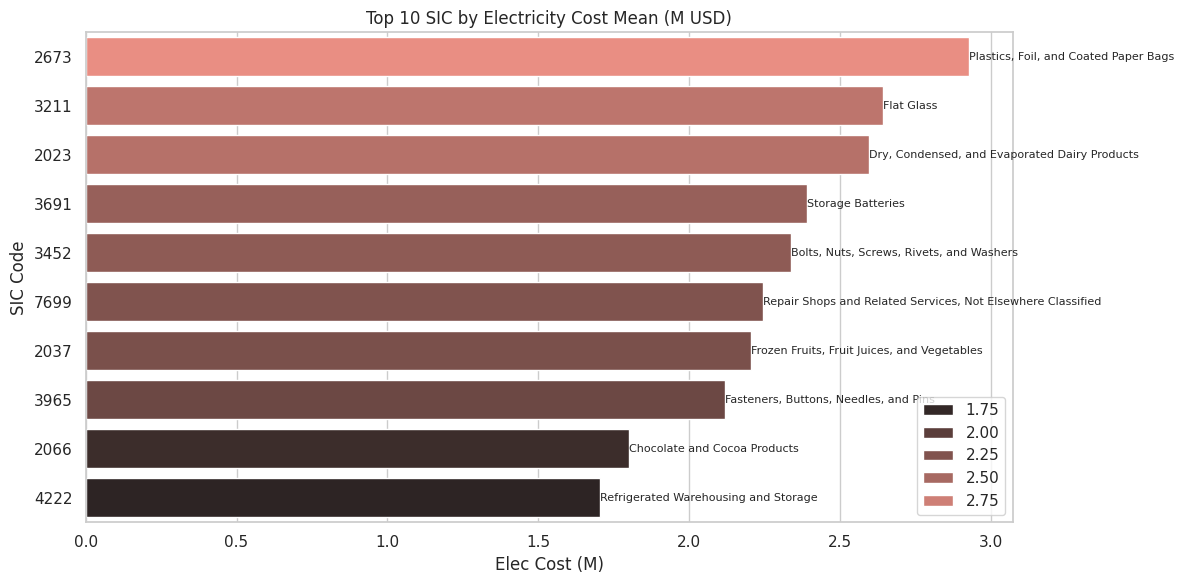

In [ ]:

elec_by_sic_mu = (work_data
               .groupby('SIC')['AnnualElec(M)']
               .mean()
               .nlargest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=elec_by_sic_mu.values, y=elec_by_sic_mu.index.astype(str),hue = elec_by_sic_mu.values, palette='dark:salmon')
plt.title("Top 10 SIC by Electricity Cost Mean (M USD)")
plt.xlabel("Elec Cost (M)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(elec_by_sic_mu.index, elec_by_sic_mu.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()

*Top 10 Industries by ROI Yrs*

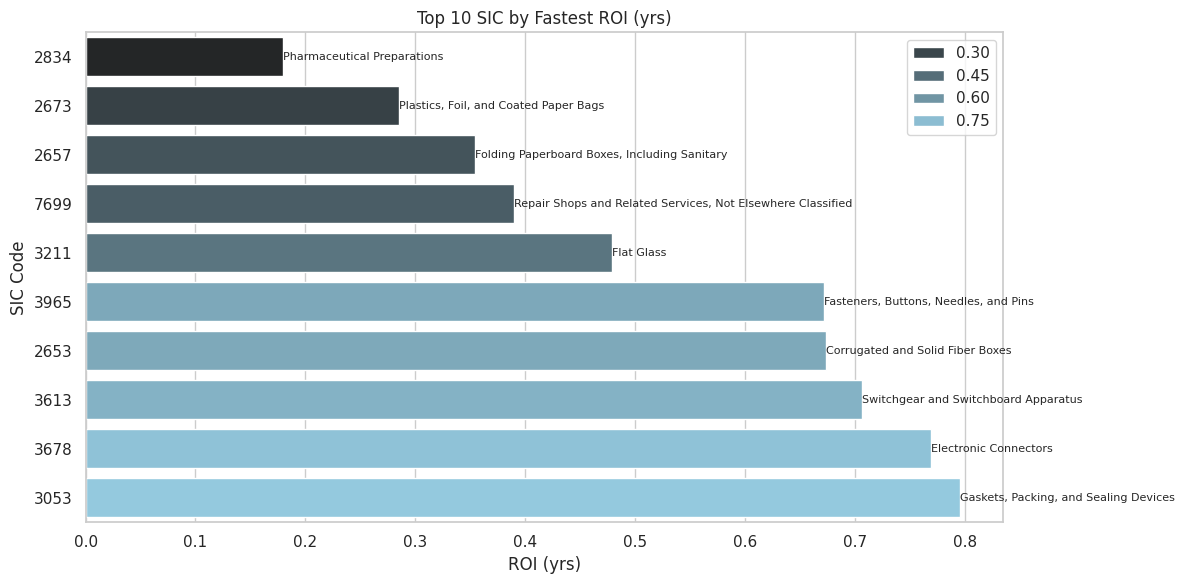

In [ ]:
roi_by_sic = (work_data
              .groupby('SIC')['ROI(yrs)']
              .mean()
              .nsmallest(10))

plt.figure(figsize=(12,6))
sns.barplot(x=roi_by_sic.values, y=roi_by_sic.index.astype(str),hue = roi_by_sic.values, palette='dark:skyblue' )
plt.title("Top 10 SIC by Fastest ROI (yrs)")
plt.xlabel("ROI (yrs)")
plt.ylabel("SIC Code")
for i,(code,val) in enumerate(zip(roi_by_sic.index, roi_by_sic.values)):
    plt.text(val, i, sic_lookup.loc[code], va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
top_10_industry_df = pd.DataFrame({
    'Major Group':      mg_counts.index.astype(str),

    'SIC Code':         sic_counts.index.astype(int),
    'SIC Industry':     [sic_lookup[s] for s in sic_counts.index],

    'Savings Code':     savings_by_sic.index.astype(int),
    'Savings Industry': [sic_lookup[s] for s in savings_by_sic.index],

    'Mean Savings Code':     savings_by_sic_mu.index.astype(int),
    'Mean Savings Industry': [sic_lookup[s] for s in savings_by_sic_mu.index],

    'ElecCost Code':    elec_by_sic.index.astype(int),
    'ElecCost Industry':[sic_lookup[s] for s in elec_by_sic.index],

    'Mean ElecCost Code':    elec_by_sic_mu.index.astype(int),
    'Mean ElecCost Industry':[sic_lookup[s] for s in elec_by_sic_mu.index],

    'ROI Code':         roi_by_sic.index.astype(int),
    'ROI Industry':     [sic_lookup[s] for s in roi_by_sic.index],
})
top_10_industry_df



,Major Group,SIC Code,SIC Industry,Savings Code,Savings Industry,Mean Savings Code,Mean Savings Industry,ElecCost Code,ElecCost Industry,Mean ElecCost Code,Mean ElecCost Industry,ROI Code,ROI Industry
0,20.0,4952,Sewerage Systems,4952,Sewerage Systems,3965,"Fasteners, Buttons, Needles, and Pins",4952,Sewerage Systems,2673,"Plastics, Foil, and Coated Paper Bags",2834,Pharmaceutical Preparations
1,34.0,2084,"Wines, Brandy, and Brandy Spirits",2084,"Wines, Brandy, and Brandy Spirits",7699,"Repair Shops and Related Services, Not Elsewhe...",2084,"Wines, Brandy, and Brandy Spirits",3211,Flat Glass,2673,"Plastics, Foil, and Coated Paper Bags"
2,36.0,3479,"Coating, Engraving, and Allied Services, Not E...",3728,"Aircraft Parts and Auxiliary Equipment, Not El...",3728,"Aircraft Parts and Auxiliary Equipment, Not El...",2026,Fluid Milk,2023,"Dry, Condensed, and Evaporated Dairy Products",2657,"Folding Paperboard Boxes, Including Sanitary"
3,49.0,2099,"Food Preparations, Not Elsewhere Classified",3479,"Coating, Engraving, and Allied Services, Not E...",2653,Corrugated and Solid Fiber Boxes,3479,"Coating, Engraving, and Allied Services, Not E...",3691,Storage Batteries,7699,"Repair Shops and Related Services, Not Elsewhe..."
4,33.0,3398,Metal Heat Treating,3965,"Fasteners, Buttons, Needles, and Pins",3452,"Bolts, Nuts, Screws, Rivets, and Washers",2836,"Biological Products, Except Diagnostic Substances",3452,"Bolts, Nuts, Screws, Rivets, and Washers",3211,Flat Glass
5,30.0,3599,Industrial and Commercial Machinery and Equipm...,7699,"Repair Shops and Related Services, Not Elsewhe...",2834,Pharmaceutical Preparations,3841,Surgical and Medical Instruments and Apparatus,7699,"Repair Shops and Related Services, Not Elsewhe...",3965,"Fasteners, Buttons, Needles, and Pins"
6,35.0,3728,"Aircraft Parts and Auxiliary Equipment, Not El...",2099,"Food Preparations, Not Elsewhere Classified",3691,Storage Batteries,3728,"Aircraft Parts and Auxiliary Equipment, Not El...",2037,"Frozen Fruits, Fruit Juices, and Vegetables",2653,Corrugated and Solid Fiber Boxes
7,28.0,8211,Elementary and Secondary Schools,3841,Surgical and Medical Instruments and Apparatus,2047,Dog and Cat Food,2099,"Food Preparations, Not Elsewhere Classified",3965,"Fasteners, Buttons, Needles, and Pins",3613,Switchgear and Switchboard Apparatus
8,26.0,2026,Fluid Milk,2836,"Biological Products, Except Diagnostic Substances",3053,"Gaskets, Packing, and Sealing Devices",2673,"Plastics, Foil, and Coated Paper Bags",2066,Chocolate and Cocoa Products,3678,Electronic Connectors
9,38.0,3089,"Plastics Products, Not Elsewhere Classified",2653,Corrugated and Solid Fiber Boxes,3469,"Metal Stampings, Not Elsewhere Classified",3211,Flat Glass,4222,Refrigerated Warehousing and Storage,3053,"Gaskets, Packing, and Sealing Devices"


*Industries that make it along most dimensional studies*

In [ ]:
primary_cols = [
    'SIC Industry',
    'Savings Industry',
    'ElecCost Industry',
    'ROI Industry'
]
all_cols = primary_cols + [
    'Mean Savings Industry',
    'Mean ElecCost Industry'
]

inds = set()
for col in all_cols:
    inds.update(top_10_industry_df[col].dropna().unique())

counts_no_mean = {
    ind: sum(ind in top_10_industry_df[col].values for col in primary_cols)
    for ind in inds
}

counts_with_mean = {
    ind: sum(ind in top_10_industry_df[col].values for col in all_cols)
    for ind in inds
}

at_least_3 = sorted([ind for ind, cnt in counts_no_mean.items() if cnt >= 3])
at_least_4_with_mean = sorted([ind for ind, cnt in counts_with_mean.items() if cnt >= 4])

# 6. Print results
print("Industries in ≥3 of the 4 primary metrics (SIC, Savings, Cost, ROI):")
for ind in at_least_3:
    print(" -", ind)

print("\nIndustries in ≥4 of the 6 metrics (including mean Savings & mean Cost):")
for ind in at_least_4_with_mean:
    print(" -", ind)


Industries in ≥3 of the 4 primary metrics (SIC, Savings, Cost, ROI):
 - Aircraft Parts and Auxiliary Equipment, Not Elsewhere Classified
 - Coating, Engraving, and Allied Services, Not Elsewhere Classified
 - Food Preparations, Not Elsewhere Classified
 - Sewerage Systems
 - Wines, Brandy, and Brandy Spirits

Industries in ≥4 of the 6 metrics (including mean Savings & mean Cost):
 - Aircraft Parts and Auxiliary Equipment, Not Elsewhere Classified
 - Fasteners, Buttons, Needles, and Pins
 - Repair Shops and Related Services, Not Elsewhere Classified


#Sector Wise Analysis#

In [ ]:
def sector_analysis(sic_code: int, df: pd.DataFrame):
    desc_lookup = df.drop_duplicates('SIC').set_index('SIC')['Description']
    industry = desc_lookup.get(sic_code, "Unknown Industry")
    print(f"\nSector {sic_code}: {industry}")
    raw = {
        'ANNUAL_SALES':            ('Annual Sales (M)',        1e6),
        'EMPLOYEES':               ('Employees',               1),
        'PLANT_AREA':              ('Plant Area (M sqft)',     1e6),
        'ANNUAL_ELECTRICITY_COST': ('Electricity Cost (M)',    1e6),
        'TOTAL_RECC_IMP_COST':     ('Implementation Cost (M)', 1e6),
        'TOTAL_RECC_SAVINGS':      ('Savings (M)',             1e6),
        'ROI_YRS':                 ('ROI (yrs)',               1),
    }
    cols = [c for c in raw if c in df.columns]
    sect = df[df['SIC'] == sic_code][cols].copy()
    if sect.empty:
        print("No data for this SIC.")
        return
    sect_scaled = pd.DataFrame({
        label: sect[col] / scale
        for col, (label, scale) in raw.items() if col in sect
    })
    stats = sect_scaled.describe().T[['count','mean','std','25%','50%','75%']]
    print(f"{industry} Summary (scaled)")
    display(stats)

    global_scaled = pd.DataFrame({
        label: df[col] / scale
        for col, (label, scale) in raw.items() if col in df
    })
    gmean = global_scaled.mean()
    gmed  = global_scaled.median()

    comp = pd.DataFrame({
        'Sector Mean':   stats['mean'],
        'Global Mean':   gmean,
        'Mean Diff':     stats['mean']   - gmean,
        'Sector Median': stats['50%'],
        'Global Median': gmed,
        'Median Diff':   stats['50%']    - gmed,
    }).rename(columns={
        'Sector Mean':   f'{industry} Mean',
        'Sector Median': f'{industry} Median'
    })

    print(f"{industry} VS Global Comparison")
    display(comp)


    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    for ax, col in zip(axes, sect_scaled.columns):
        sns.histplot(sect_scaled[col], kde=True, ax=ax,
                     color='orange', edgecolor='black', alpha=0.6)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel('Count')
    if len(sect_scaled.columns) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

    for metric in comp.index:
        cols_to_plot = [
            'Global Mean',
            f'{industry} Mean',
            'Global Median',
            f'{industry} Median'
        ]
        vals = comp.loc[metric, cols_to_plot]
        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(cols_to_plot, vals.values,
                      color=['gray','orange','lightgray','salmon'],
                      edgecolor='black')
        ax.set_title(f"{metric}: Global vs. {industry}")
        ax.set_ylabel(metric)
        ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, v*1.01,
                    f"{v:.2f}", ha='center', va='bottom', fontsize=8)
        plt.tight_layout()
        plt.show()




Sector 4952: Sewerage Systems
Sewerage Systems Summary (scaled)


,count,mean,std,25%,50%,75%
Annual Sales (M),8.0,11.763375,20.597808,1.991750,3.250000,9.060000
Employees,8.0,64.375000,89.820356,16.750000,37.500000,53.250000
Plant Area (M sqft),8.0,1.915065,3.497923,0.320000,0.711100,1.118740
Electricity Cost (M),8.0,1.134116,0.839475,0.626451,0.718464,1.196448
Implementation Cost (M),8.0,2.100614,3.839842,0.522046,0.757259,1.217618
Savings (M),8.0,0.654573,0.846573,0.231173,0.275521,0.580157
ROI (yrs),8.0,2.603187,1.151341,1.697311,2.550355,3.325389


Sewerage Systems VS Global Comparison


,Sewerage Systems Mean,Global Mean,Mean Diff,Sewerage Systems Median,Global Median,Median Diff
Annual Sales (M),11.763375,56.599560,-44.836185,3.250000,20.000000,-16.750000
Employees,64.375000,123.189394,-58.814394,37.500000,85.000000,-47.500000
Plant Area (M sqft),1.915065,0.261109,1.653956,0.711100,0.088679,0.622421
Electricity Cost (M),1.134116,0.831207,0.302909,0.718464,0.566793,0.151671
Implementation Cost (M),2.100614,0.737957,1.362657,0.757259,0.521402,0.235856
Savings (M),0.654573,0.369121,0.285453,0.275521,0.206160,0.069362
ROI (yrs),2.603187,2.261986,0.341201,2.550355,2.243753,0.306602


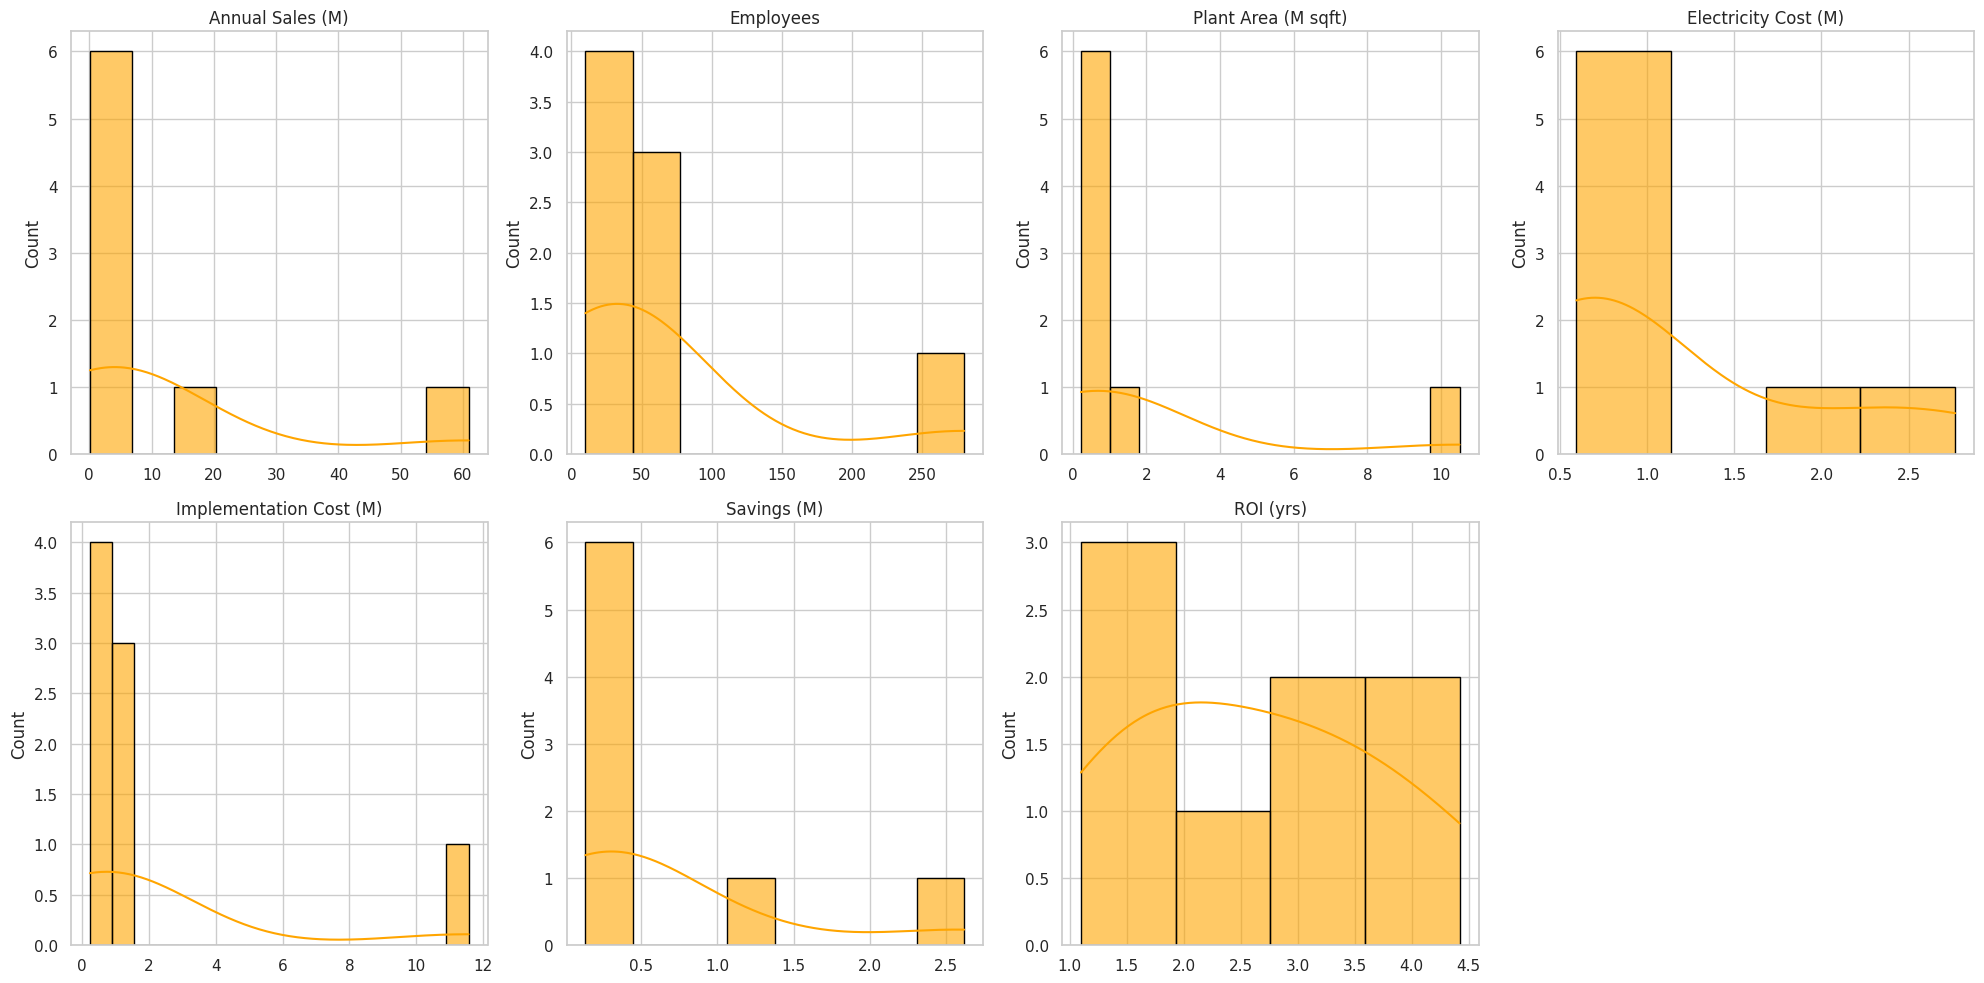

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


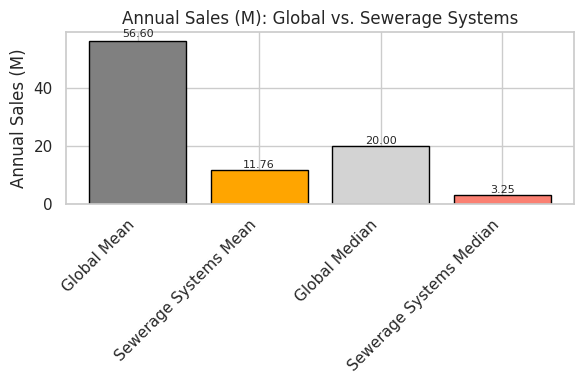

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


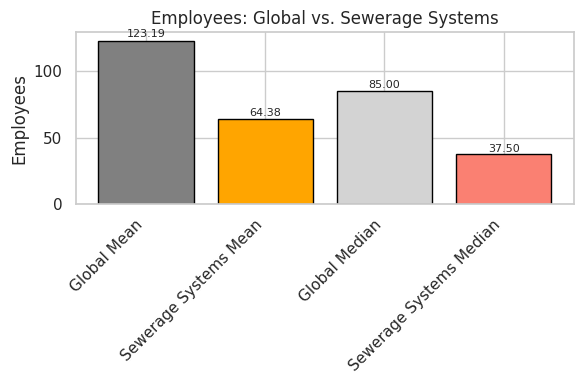

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


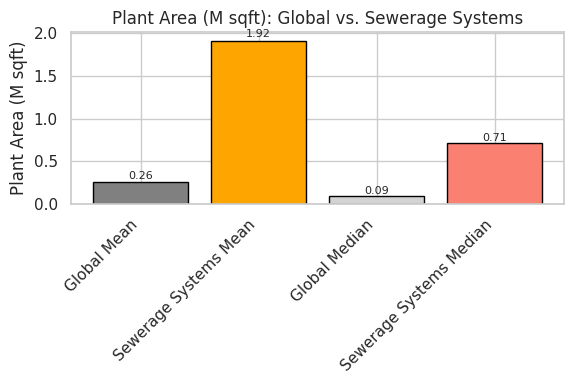

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


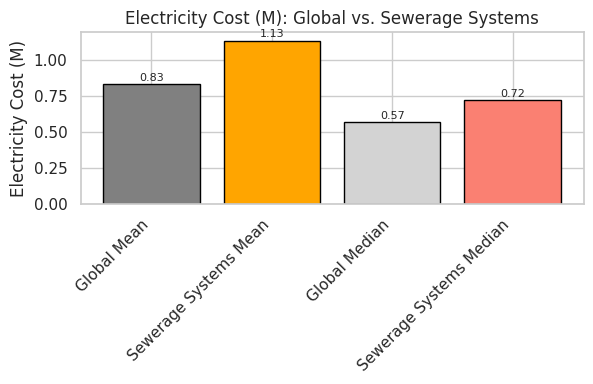

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


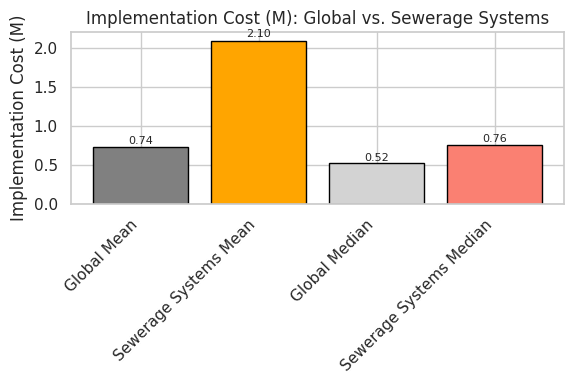

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


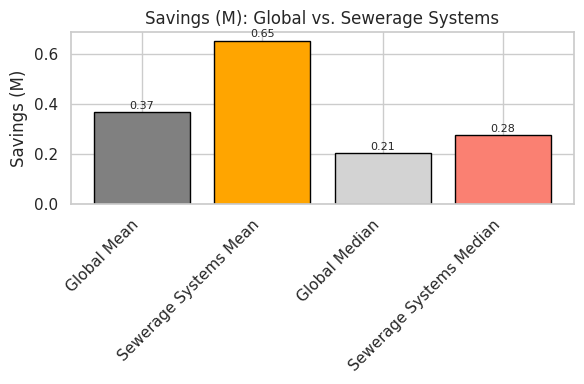

/tmp/ipython-input-64-1919313493.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cols_to_plot, rotation=45, ha='right')


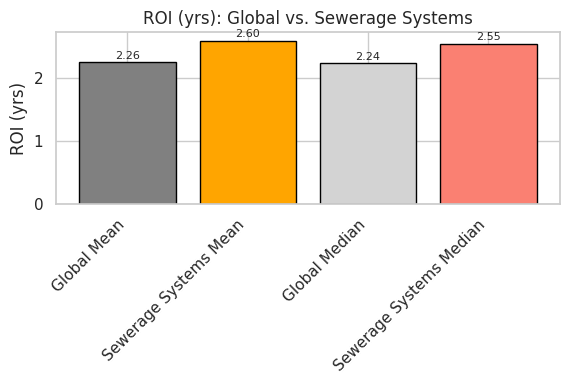

In [ ]:
sector_analysis(4952, df)


#Sector Comparisons#

In [ ]:
def compare_sic_metrics(sic_list, df):
    raw = {
        'ANNUAL_SALES':            ('Annual Sales (M)',        1e6),
        'EMPLOYEES':               ('Employees',               1),
        'PLANT_AREA':              ('Plant Area (M sqft)',     1e6),
        'ANNUAL_ELECTRICITY_COST': ('Electricity Cost (M)',    1e6),
        'TOTAL_RECC_IMP_COST':     ('Implementation Cost (M)', 1e6),
        'TOTAL_RECC_SAVINGS':      ('Savings (M)',             1e6),
        'ROI_YRS':                 ('ROI (yrs)',               1),
    }
    global_scaled = pd.DataFrame({
        label: df[col] / scale
        for col, (label, scale) in raw.items() if col in df
    })
    gmean = global_scaled.mean()
    gmed  = global_scaled.median()

    desc_lookup = df.drop_duplicates('SIC').set_index('SIC')['Description']
    data_means = {'Global': gmean}
    data_meds  = {'Global': gmed}
    for sic in sic_list:
        sect = df[df['SIC'] == sic]
        sect_scaled = pd.DataFrame({
            label: sect[col] / scale
            for col, (label, scale) in raw.items() if col in sect
        })
        industry = desc_lookup.get(sic, str(sic))
        data_means[industry] = sect_scaled.mean()
        data_meds[industry]  = sect_scaled.median()

    means_df   = pd.DataFrame(data_means)
    medians_df = pd.DataFrame(data_meds)

    sns.set_theme(style="whitegrid")
    series_count = len(means_df.columns)
    colors_means = sns.color_palette("tab10", series_count)

    fig, axes = plt.subplots(2, 4, figsize=(24, 14))
    axes = axes.flatten()
    for ax, metric in zip(axes, means_df.index):
        vals = means_df.loc[metric]
        bars = ax.bar(vals.index, vals.values,
                      color=colors_means, edgecolor='black')
        ax.set_title(f"Mean {metric}")
        ax.set_ylabel(metric)
        ax.set_xticklabels(vals.index, rotation=45, ha='right')
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v * 1.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    if len(means_df.index) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

    colors_meds = sns.color_palette("Set2", series_count)

    fig, axes = plt.subplots(2, 4, figsize=(24, 14))
    axes = axes.flatten()
    for ax, metric in zip(axes, medians_df.index):
        vals = medians_df.loc[metric]
        bars = ax.bar(vals.index, vals.values,
                      color=colors_meds, edgecolor='black')
        ax.set_title(f"Median {metric}")
        ax.set_ylabel(metric)
        ax.set_xticklabels(vals.index, rotation=45, ha='right')
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v * 1.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    if len(medians_df.index) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-66-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:46: UserWarning: set_ticklabels() should only be used with a

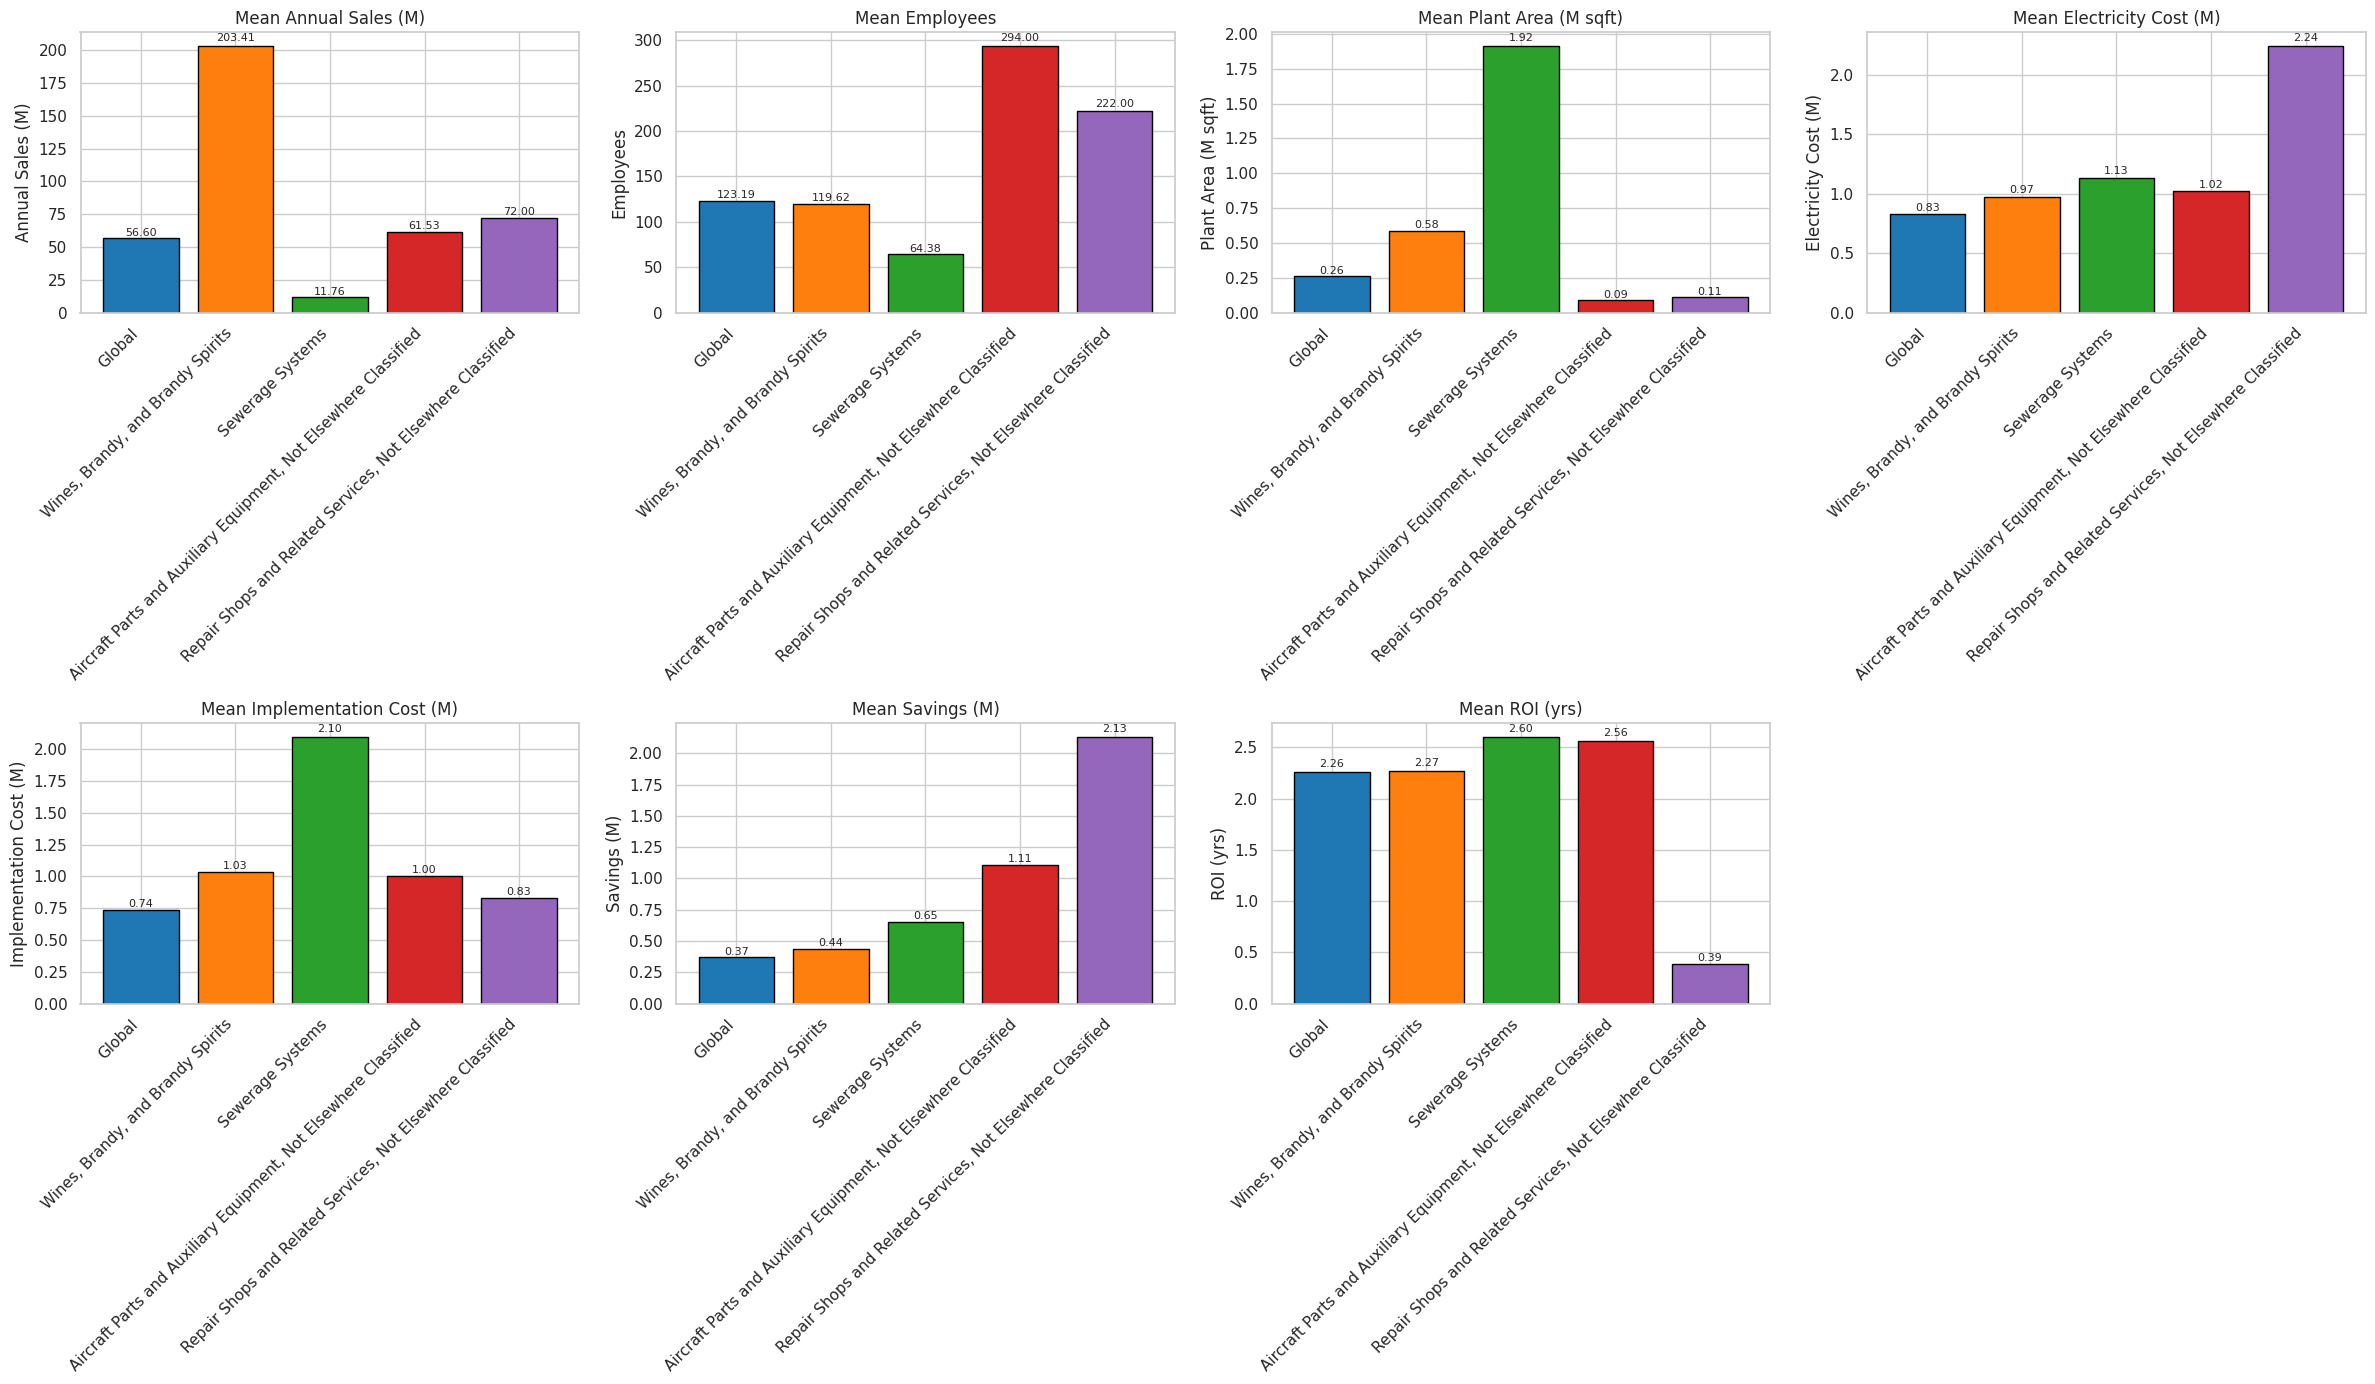

/tmp/ipython-input-66-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right')
/tmp/ipython-input-66-3179174654.py:65: UserWarning: set_ticklabels() should only be used with a

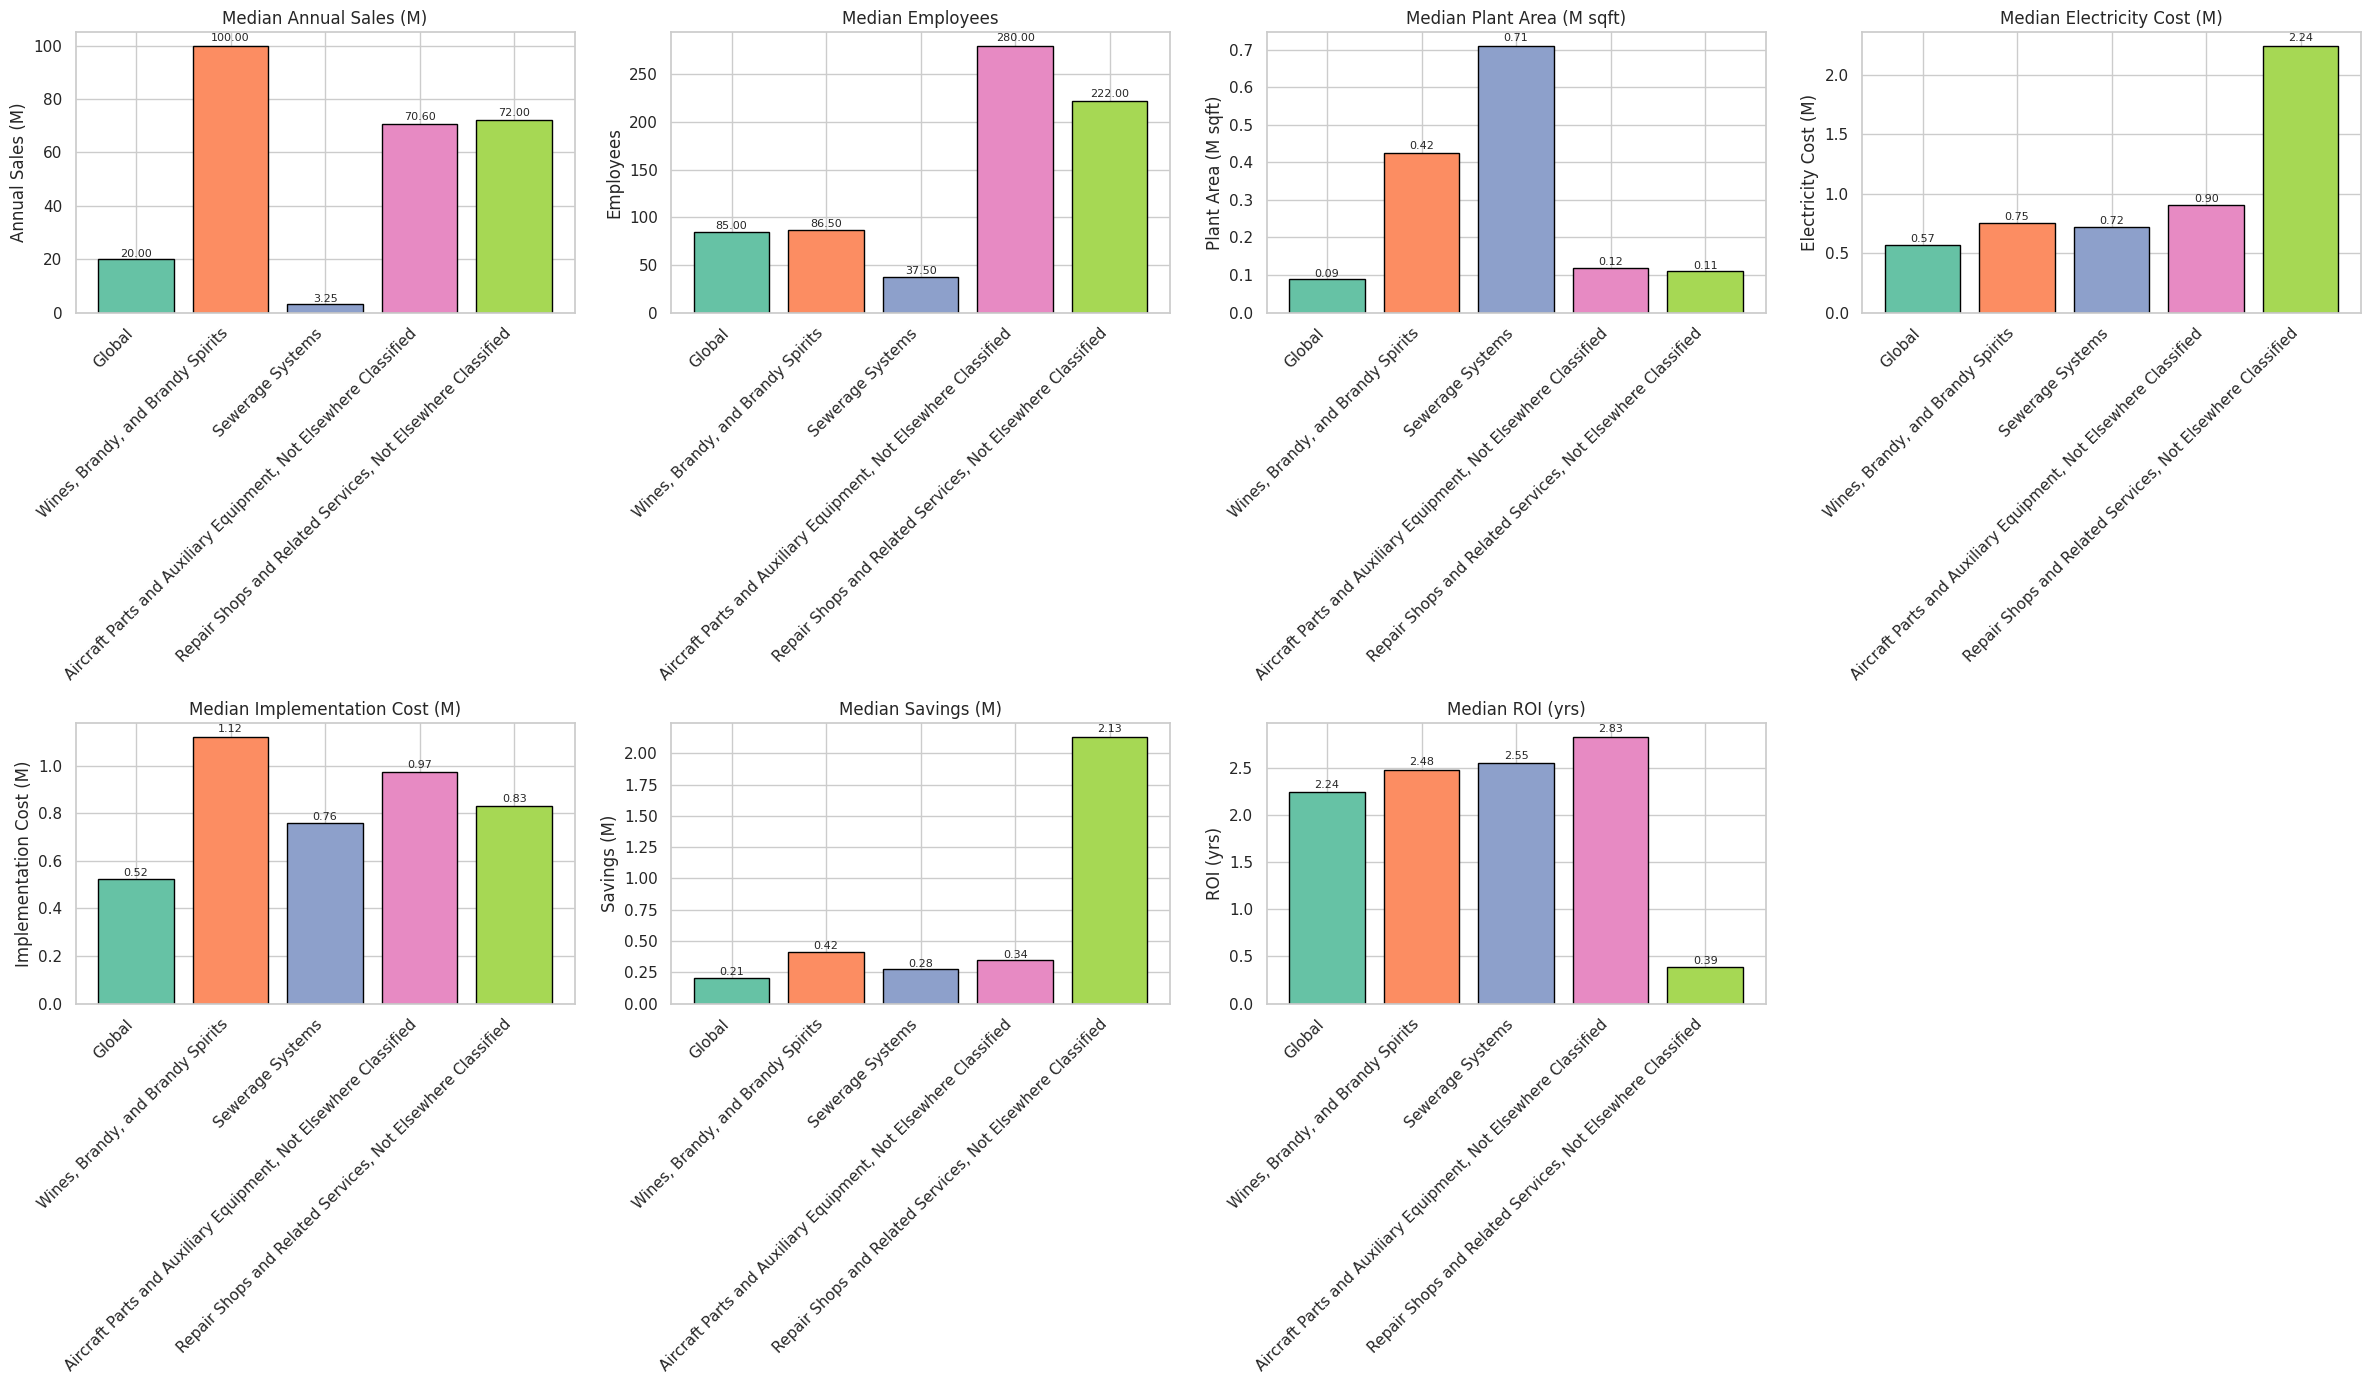

In [ ]:
compare_sic_metrics([2084, 4952, 3728,7699], df)


#Similarity Analysis#

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler
import textwrap

def similarity_analysis(sic_list, df):
    df_scaled = df.copy()
    for c in ['ANNUAL_SALES','PLANT_AREA',
              'ANNUAL_ELECTRICITY_COST',
              'TOTAL_RECC_IMP_COST',
              'TOTAL_RECC_SAVINGS']:
        df_scaled[c] /= 1e6

    metrics = [
        'ANNUAL_SALES','EMPLOYEES','PLANT_AREA',
        'ANNUAL_ELECTRICITY_COST','TOTAL_RECC_IMP_COST',
        'TOTAL_RECC_SAVINGS','ROI_YRS'
    ]
    rename_map = {
        'ANNUAL_SALES':            'Sales (M)',
        'EMPLOYEES':               'Employees',
        'PLANT_AREA':              'Area (M sqft)',
        'ANNUAL_ELECTRICITY_COST': 'ElecCost (M)',
        'TOTAL_RECC_IMP_COST':     'ImplCost (M)',
        'TOTAL_RECC_SAVINGS':      'Savings (M)',
        'ROI_YRS':                 'ROI (yrs)'
    }
  #Vector of 7 dimensions per feature mean per SIC
    prof = (
        df_scaled[df_scaled['SIC'].isin(sic_list)]
          .groupby('SIC')[metrics]
          .mean()
          .rename(columns=rename_map)
    )

    #Standardise these vectors 1 per industry
    X = StandardScaler().fit_transform(prof.values)
    dist_vec = pdist(X, metric='euclidean')#Compute euclidean distance between these vectors
    linkage = hierarchy.linkage(dist_vec, method='ward')


    desc = df_scaled.drop_duplicates('SIC').set_index('SIC')['Description']
    labels = []
    for sic in prof.index:
        short = textwrap.shorten(desc.get(sic,''), width=25, placeholder='…')
        labels.append(f"{sic}\n{short}")

    plt.figure(figsize=(14,5))
    dn = hierarchy.dendrogram(
        linkage,
        labels=labels,
        orientation='top',
        leaf_rotation=45,
        leaf_font_size=10,
        color_threshold=0
    )
    plt.title("Sector Clustering (Euclidean Ward)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()
    #Correlation between the 7dim vectros Red means very similar industries,blue is different
    corr = prof.T.corr()
    print(prof,corr)
    cg = sns.clustermap(
        corr,
        cmap='vlag',
        center=0,
        linewidths=0.8,
        figsize=(12,12),
        annot=True,
        fmt=".2f",
        annot_kws={'size':8},
        xticklabels=labels,
        yticklabels=labels
    )
    cg.fig.suptitle("Sector Similarity: Pearson Correlation", y=1.02)
    plt.show()


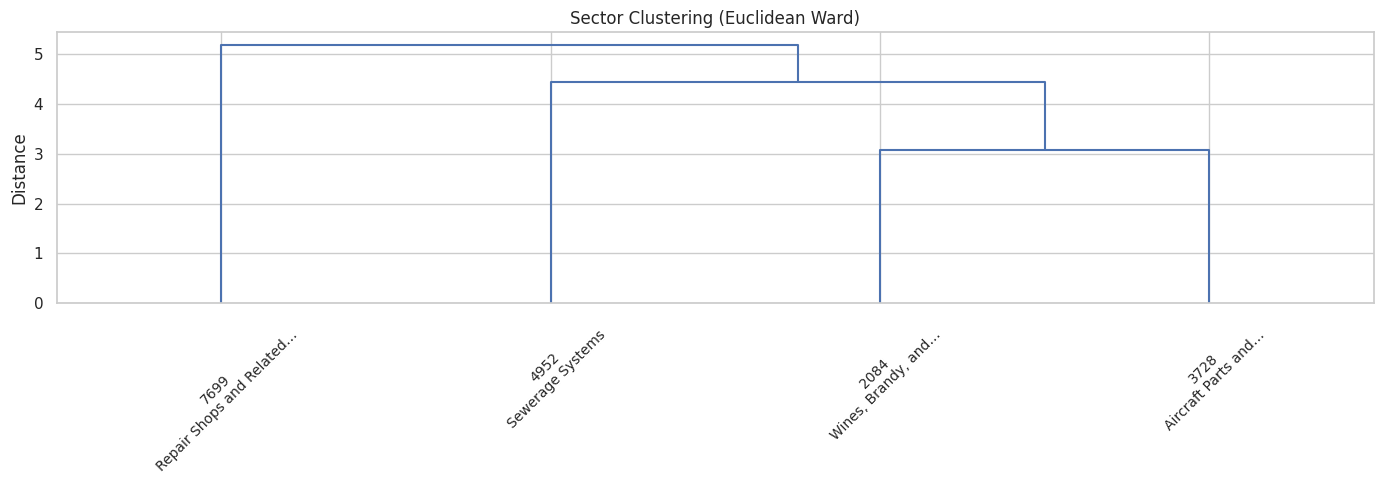

       Sales (M)  Employees  Area (M sqft)  ElecCost (M)  ImplCost (M)  \
SIC                                                                      
2084  203.407500    119.625       0.582940      0.974852      1.033664   
3728   61.533333    294.000       0.091000      1.018300      1.003308   
4952   11.763375     64.375       1.915065      1.134116      2.100614   
7699   72.000000    222.000       0.110000      2.243881      0.831591   

      Savings (M)  ROI (yrs)  
SIC                           
2084     0.437992   2.272217  
3728     1.105295   2.561147  
4952     0.654573   2.603187  
7699     2.133723   0.389737   SIC       2084      3728      4952      7699
SIC                                         
2084  1.000000  0.572521  0.534145  0.662766
3728  0.572521  1.000000  0.998622  0.993319
4952  0.534145  0.998622  1.000000  0.986419
7699  0.662766  0.993319  0.986419  1.000000


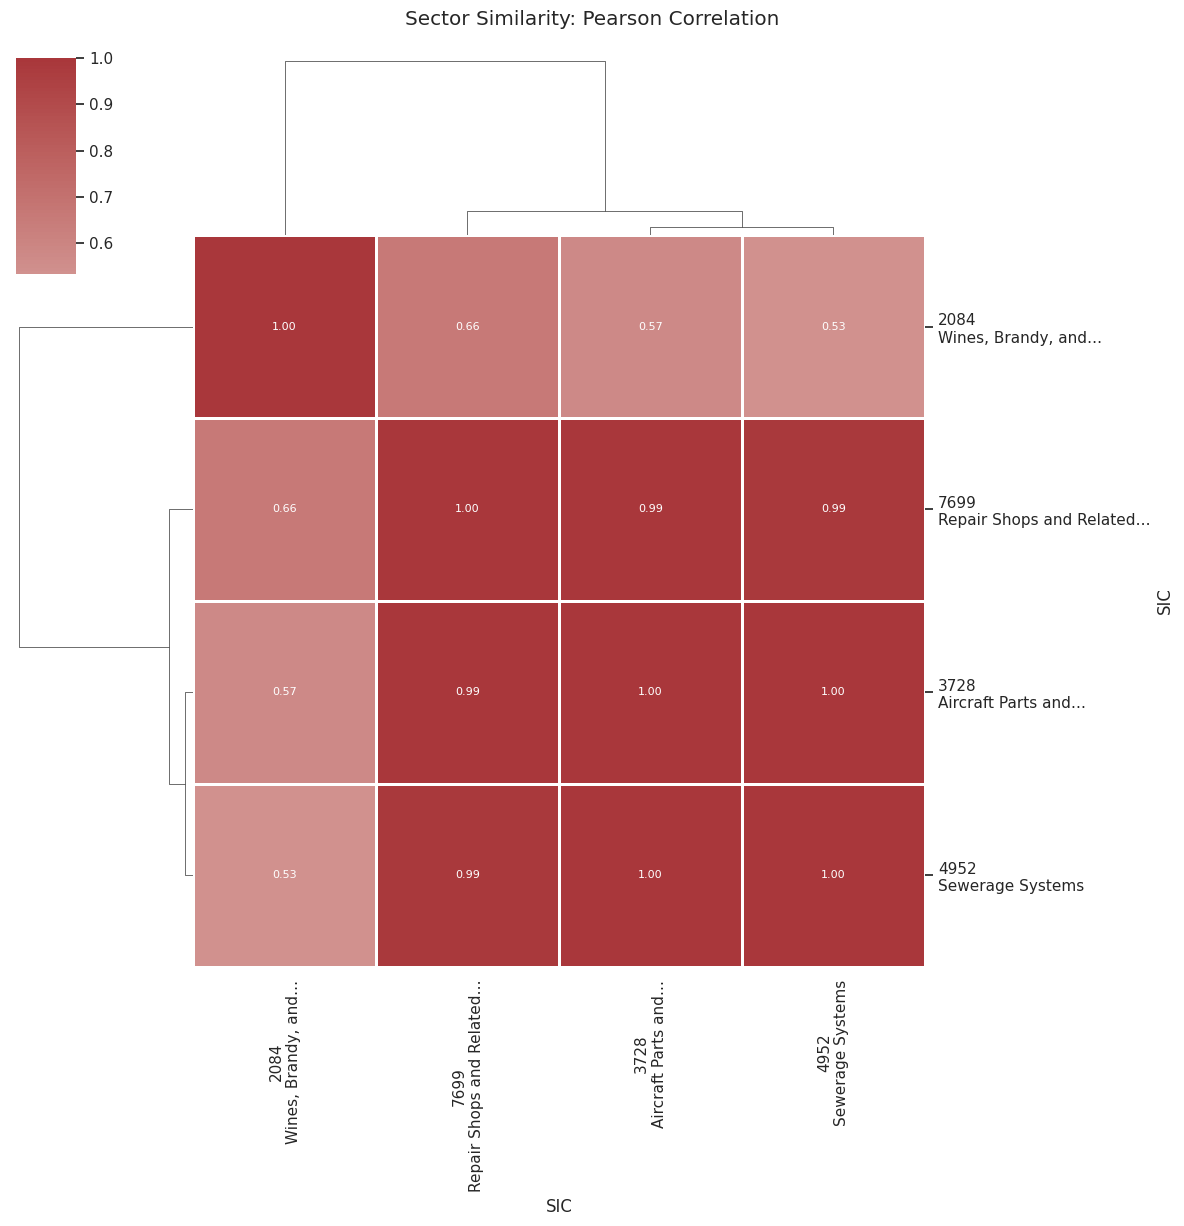

In [ ]:
similarity_analysis([2084, 4952, 3728,7699], df)

Two sectors with profiles (10, 20, 30) and (20, 40, 60) have perfect correlation r=1—they rise and fall in lock-step—even though one is always twice as large.

But those same two are quite far apart in Euclidean distance, because the absolute gap is big.

Correlation thus answers a different question:

“When this industry spikes above its own average, does that other one also spike above its own average?”

Whereas distance answers:

“How far apart are they in absolute (but standardized) magnitude space?”